# HR Attrition — Exploratory Data Analysis & Model Training

End-to-end analysis of the IBM HR Analytics dataset:  
**Data Cleaning → EDA → Model Training & Evaluation**

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

c:\Users\seane\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

In [2]:
df = pd.read_csv(r'D:\Sunway\Bachelor of Information System (Data Analytics)\Capstone Project\HRADSS\data\HR-Emp-Att.csv')

In [3]:
df.head(10) # To check first 10 row of data

,EmployeeID,EmployeeName,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,EMP0001,Tomoko Singh,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,EMP0002,Ming Tan,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,EMP0004,Zhi Ling,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,EMP0005,Kaito Tanaka,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,EMP0007,Yong Chen,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,EMP0008,Hassan Abdullah,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,EMP0010,Yuna Raj,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,EMP0011,Aina Bai,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,EMP0012,Zulkifli Wang,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,EMP0013,Ying Hassan,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


## 3. Data Cleaning & Encoding

In [4]:
# Drop unnecessary columns
df_cleaned = df.drop(['EmployeeID', 'EmployeeName', 'EmployeeCount', 'StandardHours', 'Over18'], axis=1, errors='ignore')

In [5]:
# To check on the data types
df_cleaned.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole  

In [6]:
df_cleaned.head(10) # To check on cleaned dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,No,13,3,3,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Yes,20,4,1,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,No,22,4,2,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,No,21,4,2,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,No,13,3,2,2,17,3,2,7,7,7,7


In [7]:
# Check for missing values
print(df.isnull().sum().sum(), "missing values found")

0 missing values found


In [8]:
# Copy the cleaned dataset for encoding
encoded_df = df_cleaned.copy()

In [9]:
# Manual Encoding

# Attrition (target variable)
choices_attrition = [0, 1]
conditions = [
    (encoded_df["Attrition"] == "No"),
    (encoded_df["Attrition"] == "Yes")
]
encoded_df["Attrition"] = np.select(conditions, choices_attrition, default=-1)

# WorkLifeBalance
choices_workLifeBalance = ["Bad", "Good", "Better", "Best"]
conditions = [
    (encoded_df["WorkLifeBalance"] == 1),
    (encoded_df["WorkLifeBalance"] == 2),
    (encoded_df["WorkLifeBalance"] == 3),
    (encoded_df["WorkLifeBalance"] == 4)
]
encoded_df["WorkLifeBalance"] = np.select(conditions, choices_workLifeBalance, default="Unknown")

# Education
choices_education = ["Below College", "College", "Bachelor", "Master", "Doctor"]
conditions = [
    (encoded_df["Education"] == 1),
    (encoded_df["Education"] == 2),
    (encoded_df["Education"] == 3),
    (encoded_df["Education"] == 4),
    (encoded_df["Education"] == 5)
]
encoded_df["Education"] = np.select(conditions, choices_education, default="Unknown")

# Environment Satisfaction
choices = ["Low", "Medium", "High", "Very High"]
conditions = [
    (encoded_df["EnvironmentSatisfaction"] == 1),
    (encoded_df["EnvironmentSatisfaction"] == 2),
    (encoded_df["EnvironmentSatisfaction"] == 3),
    (encoded_df["EnvironmentSatisfaction"] == 4)
]
encoded_df["EnvironmentSatisfaction"] = np.select(conditions, choices, default="Unknown")

# Job Involvement
conditions = [
    (encoded_df["JobInvolvement"] == 1),
    (encoded_df["JobInvolvement"] == 2),
    (encoded_df["JobInvolvement"] == 3),
    (encoded_df["JobInvolvement"] == 4)
]
encoded_df["JobInvolvement"] = np.select(conditions, choices, default="Unknown")

# Job Satisfaction
conditions = [
    (encoded_df["JobSatisfaction"] == 1),
    (encoded_df["JobSatisfaction"] == 2),
    (encoded_df["JobSatisfaction"] == 3),
    (encoded_df["JobSatisfaction"] == 4)
]
encoded_df["JobSatisfaction"] = np.select(conditions, choices, default="Unknown")

# Relationship Satisfaction
conditions = [
    (encoded_df["RelationshipSatisfaction"] == 1),
    (encoded_df["RelationshipSatisfaction"] == 2),
    (encoded_df["RelationshipSatisfaction"] == 3),
    (encoded_df["RelationshipSatisfaction"] == 4)
]
encoded_df["RelationshipSatisfaction"] = np.select(conditions, choices, default="Unknown")

# Performance Rating
choices_performanceRating = ["Low", "Good", "Excellent", "Outstanding"]
conditions = [
    (encoded_df["PerformanceRating"] == 1),
    (encoded_df["PerformanceRating"] == 2),
    (encoded_df["PerformanceRating"] == 3),
    (encoded_df["PerformanceRating"] == 4)
]
encoded_df["PerformanceRating"] = np.select(conditions, choices_performanceRating, default="Unknown")

# Stock Option Level
choices_stockOptionLevel = ["Basic", "Standard", "Advanced", "Elite"]
conditions = [
    (encoded_df["StockOptionLevel"] == 0),
    (encoded_df["StockOptionLevel"] == 1),
    (encoded_df["StockOptionLevel"] == 2),
    (encoded_df["StockOptionLevel"] == 3)
]
encoded_df["StockOptionLevel"] = np.select(conditions, choices_stockOptionLevel, default="Unknown")

In [10]:
# One-hot encode categorical columns (drop_first=False keeps every category,
# e.g. both OverTime_Yes and OverTime_No, so SHAP can attribute each one separately
encoded_df['JobLevel'] = encoded_df['JobLevel'].astype(str)  # 5 discrete levels, treat as categorical
categorical_cols = encoded_df.select_dtypes(include='object').columns.tolist()
encoded_df = pd.get_dummies(encoded_df, columns=categorical_cols, drop_first=False, dtype=int)

In [11]:
encoded_df.head(10) # To check on the new encoded dataset

,Age,Attrition,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,Education_Bachelor,Education_Below College,Education_College,Education_Doctor,Education_Master,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,EnvironmentSatisfaction_High,EnvironmentSatisfaction_Low,EnvironmentSatisfaction_Medium,EnvironmentSatisfaction_Very High,Gender_Female,Gender_Male,JobInvolvement_High,JobInvolvement_Low,JobInvolvement_Medium,JobInvolvement_Very High,JobLevel_1,JobLevel_2,JobLevel_3,JobLevel_4,JobLevel_5,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,JobSatisfaction_High,JobSatisfaction_Low,JobSatisfaction_Medium,JobSatisfaction_Very High,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes,PerformanceRating_Excellent,PerformanceRating_Outstanding,RelationshipSatisfaction_High,RelationshipSatisfaction_Low,RelationshipSatisfaction_Medium,RelationshipSatisfaction_Very High,StockOptionLevel_Advanced,StockOptionLevel_Basic,StockOptionLevel_Elite,StockOptionLevel_Standard,WorkLifeBalance_Bad,WorkLifeBalance_Best,WorkLifeBalance_Better,WorkLifeBalance_Good
0,41,1,1102,1,94,5993,19479,8,11,8,0,6,4,0,5,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,1,0,0,1,0,0,0,1,0,0,1,0,0,0
1,49,0,279,8,61,5130,24907,1,23,10,3,10,7,1,7,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0
2,37,1,1373,2,92,2090,2396,6,15,7,3,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,0,1,0
3,33,0,1392,3,56,2909,23159,1,11,8,3,8,7,3,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0
4,27,0,591,2,40,3468,16632,9,12,6,3,2,2,2,2,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0
5,32,0,1005,2,79,3068,11864,0,13,8,2,7,7,3,6,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1
6,59,0,1324,3,81,2670,9964,4,20,12,3,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,1
7,30,0,1358,24,67,2693,13335,1,22,1,2,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0
8,38,0,216,23,44,9526,8787,0,21,10,2,9,7,1,8,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
9,36,0,1299,27,94,5237,16577,6,13,17,3,7,7,7,7,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1


In [12]:
encoded_df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,Education_Bachelor,Education_Below College,Education_College,Education_Doctor,Education_Master,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,EnvironmentSatisfaction_High,EnvironmentSatisfaction_Low,EnvironmentSatisfaction_Medium,EnvironmentSatisfaction_Very High,Gender_Female,Gender_Male,JobInvolvement_High,JobInvolvement_Low,JobInvolvement_Medium,JobInvolvement_Very High,JobLevel_1,JobLevel_2,JobLevel_3,JobLevel_4,JobLevel_5,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,JobSatisfaction_High,JobSatisfaction_Low,JobSatisfaction_Medium,JobSatisfaction_Very High,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes,PerformanceRating_Excellent,PerformanceRating_Outstanding,RelationshipSatisfaction_High,RelationshipSatisfaction_Low,RelationshipSatisfaction_Medium,RelationshipSatisfaction_Very High,StockOptionLevel_Advanced,StockOptionLevel_Basic,StockOptionLevel_Elite,StockOptionLevel_Standard,WorkLifeBalance_Bad,WorkLifeBalance_Best,WorkLifeBalance_Better,WorkLifeBalance_Good
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.00000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,65.891156,6502.931293,14313.103401,2.693197,15.209524,11.279592,2.799320,7.008163,4.229252,2.187755,4.123129,0.102041,0.188435,0.709524,0.042857,0.653741,0.303401,0.389116,0.115646,0.191837,0.032653,0.270748,0.018367,0.412245,0.108163,0.315646,0.055782,0.089796,0.308163,0.193197,0.195238,0.303401,0.400000,0.600000,0.590476,0.056463,0.255102,0.097959,0.369388,0.363265,0.148299,0.072109,0.046939,0.089116,0.035374,0.176190,0.069388,0.098639,0.054422,0.198639,0.221769,0.056463,0.30068,0.196599,0.190476,0.312245,0.222449,0.457823,0.319728,0.717007,0.282993,0.846259,0.153741,0.312245,0.187755,0.206122,0.293878,0.107483,0.429252,0.057823,0.405442,0.054422,0.104082,0.607483,0.234014
std,9.135373,0.367863,403.509100,8.106864,20.329428,4707.956783,7117.786044,2.498009,3.659938,7.780782,1.289271,6.126525,3.623137,3.222430,3.568136,0.302805,0.391193,0.454137,0.202604,0.475939,0.459884,0.487716,0.319909,0.393879,0.177787,0.444498,0.134321,0.492406,0.310692,0.464931,0.229579,0.285986,0.461892,0.394941,0.396519,0.459884,0.490065,0.490065,0.491913,0.230891,0.436067,0.297361,0.482803,0.481104,0.355517,0.258756,0.211580,0.285008,0.184786,0.381112,0.254199,0.298279,0.226925,0.399112,0.415578,0.230891,0.45871,0.397561,0.392810,0.463567,0.416033,0.498387,0.466530,0.450

## 4. Exploratory Data Analysis (EDA)

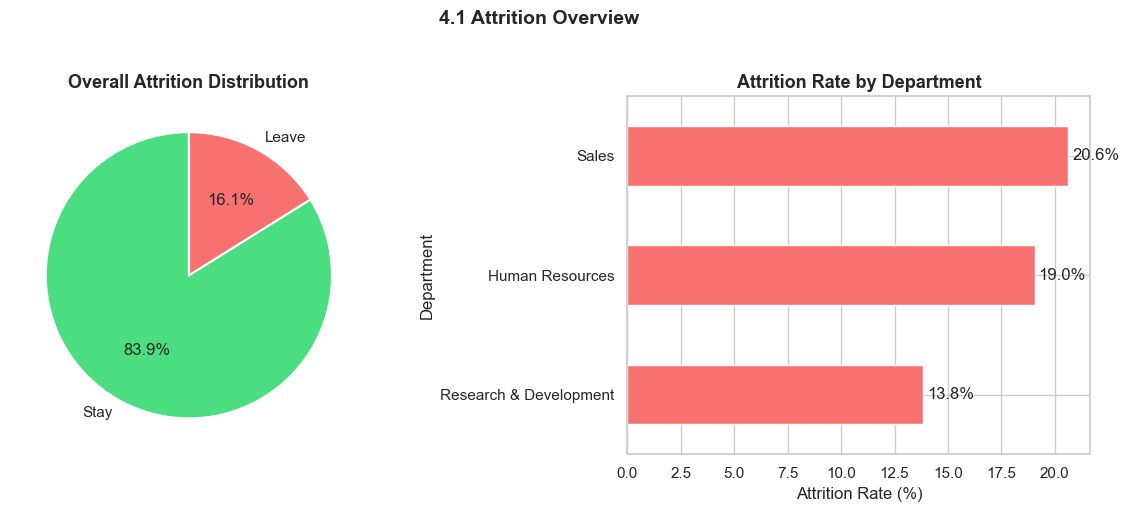

In [13]:
# 4.1 Attrition Overview
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_cleaned['Attrition'].value_counts()
axes[0].pie(counts, labels=['Stay', 'Leave'], autopct='%1.1f%%',
            colors=['#4ade80', '#f87171'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Overall Attrition Distribution', fontsize=13, fontweight='bold')

dept_attr = df_cleaned.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
dept_attr['Yes'].sort_values().plot(kind='barh', ax=axes[1], color='#f87171')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3)
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')

plt.suptitle('4.1 Attrition Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

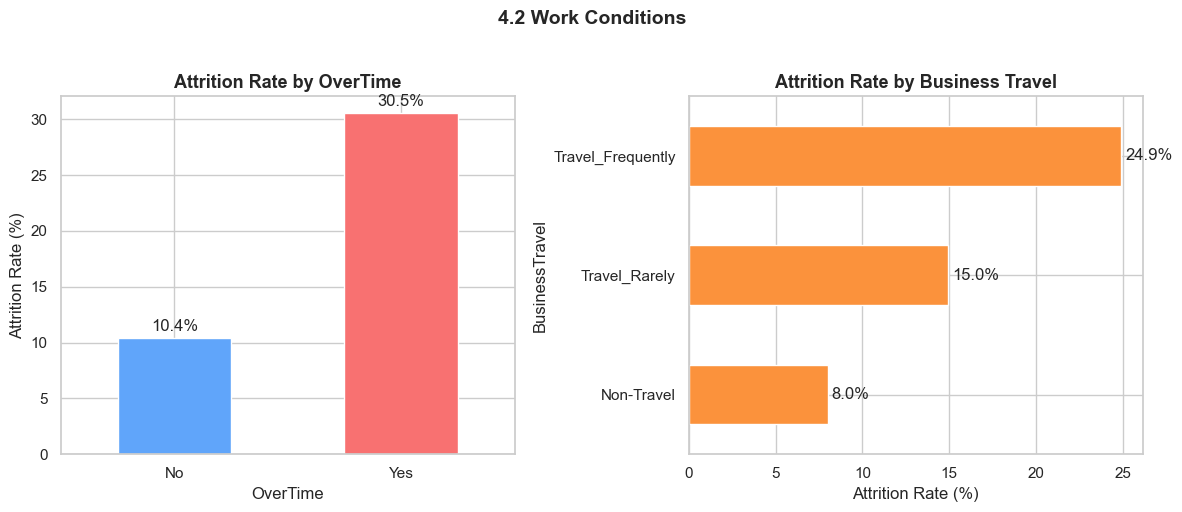

In [14]:
# 4.2 Work Conditions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ot_attr = df_cleaned.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100
ot_attr['Yes'].plot(kind='bar', ax=axes[0], color=['#60a5fa', '#f87171'])
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', padding=3)
axes[0].set_xlabel('OverTime')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by OverTime', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

bt_attr = df_cleaned.groupby('BusinessTravel')['Attrition'].value_counts(normalize=True).unstack() * 100
bt_attr['Yes'].sort_values().plot(kind='barh', ax=axes[1], color='#fb923c')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3)
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Business Travel', fontsize=13, fontweight='bold')

plt.suptitle('4.2 Work Conditions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

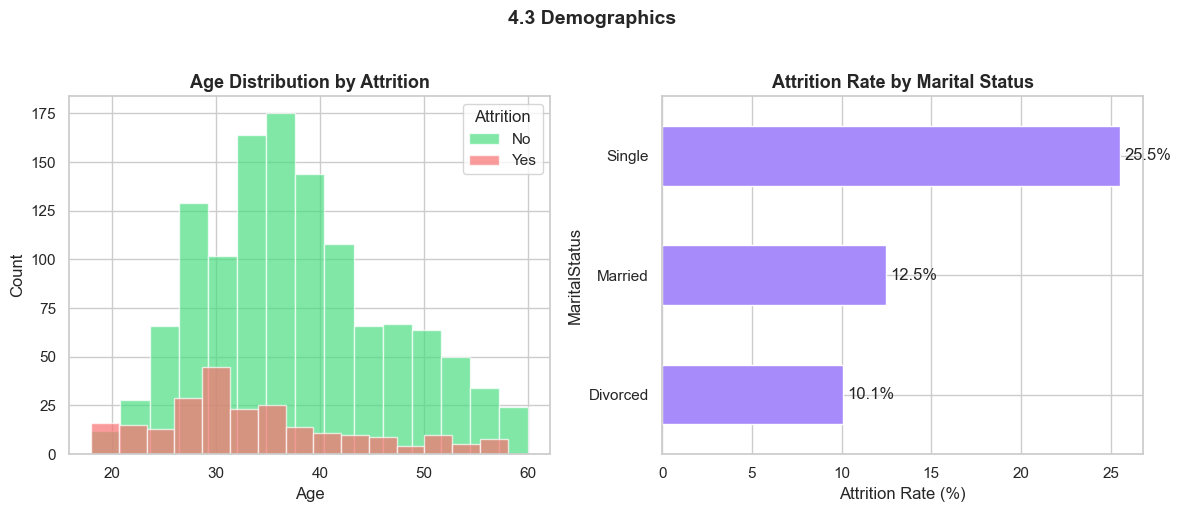

In [15]:
# 4.3 Demographics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, color in [('No', '#4ade80'), ('Yes', '#f87171')]:
    axes[0].hist(df_cleaned[df_cleaned['Attrition'] == label]['Age'],
                 bins=15, alpha=0.7, label=label, color=color)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Attrition', fontsize=13, fontweight='bold')
axes[0].legend(title='Attrition')

ms_attr = df_cleaned.groupby('MaritalStatus')['Attrition'].value_counts(normalize=True).unstack() * 100
ms_attr['Yes'].sort_values().plot(kind='barh', ax=axes[1], color='#a78bfa')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3)
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Marital Status', fontsize=13, fontweight='bold')

plt.suptitle('4.3 Demographics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

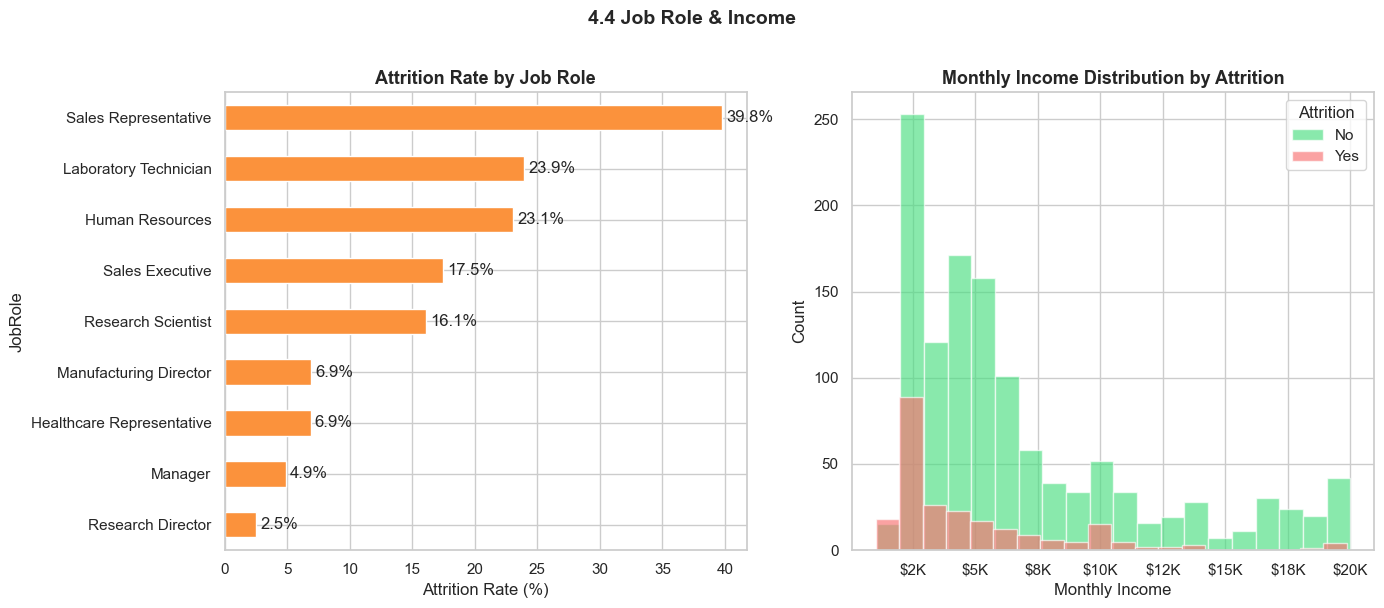

In [16]:
# 4.4 Job Role & Income
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

jr_attr = df_cleaned.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
jr_attr['Yes'].sort_values().plot(kind='barh', ax=axes[0], color='#fb923c')
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', padding=3)
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by Job Role', fontsize=13, fontweight='bold')

for label, color in [('No', '#4ade80'), ('Yes', '#f87171')]:
    subset = df_cleaned[df_cleaned['Attrition'] == label]['MonthlyIncome']
    axes[1].hist(subset, bins=20, alpha=0.65, label=label, color=color)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_xlabel('Monthly Income')
axes[1].set_ylabel('Count')
axes[1].set_title('Monthly Income Distribution by Attrition', fontsize=13, fontweight='bold')
axes[1].legend(title='Attrition')

plt.suptitle('4.4 Job Role & Income', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

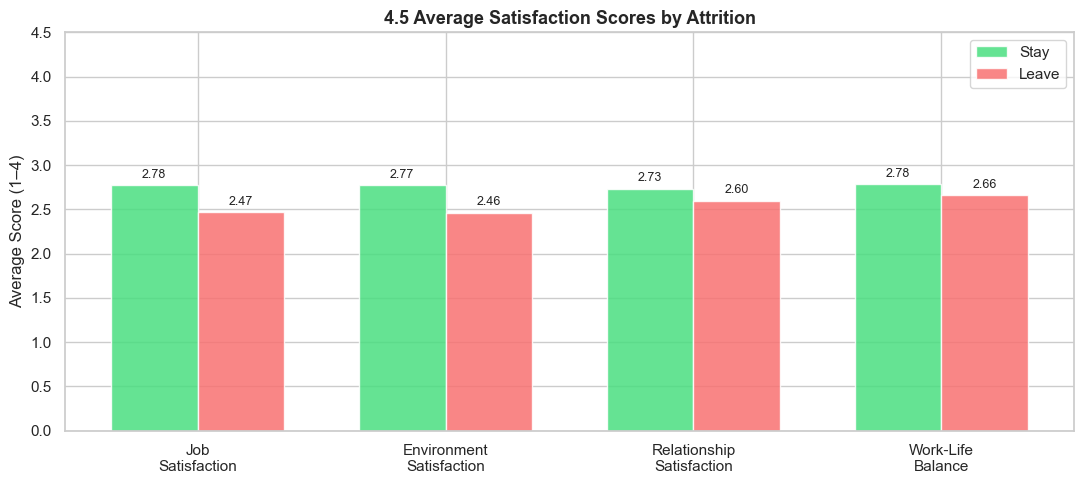

In [17]:
# 4.5 Satisfaction Scores
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']
sat_means = df_cleaned.groupby('Attrition')[sat_cols].mean()

x_pos = np.arange(len(sat_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x_pos - width/2, sat_means.loc['No'],  width, label='Stay',  color='#4ade80', alpha=0.85)
bars2 = ax.bar(x_pos + width/2, sat_means.loc['Yes'], width, label='Leave', color='#f87171', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(['Job\nSatisfaction', 'Environment\nSatisfaction',
                    'Relationship\nSatisfaction', 'Work-Life\nBalance'], fontsize=11)
ax.set_ylabel('Average Score (1–4)')
ax.set_ylim(0, 4.5)
ax.set_title('4.5 Average Satisfaction Scores by Attrition', fontsize=13, fontweight='bold')
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\seane\AppData\Local\Temp\ipykernel_19808\2408827944.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Attrition', y='YearsAtCompany',
C:\Users\seane\AppData\Local\Temp\ipykernel_19808\2408827944.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Attrition', y='YearsSinceLastPromotion',


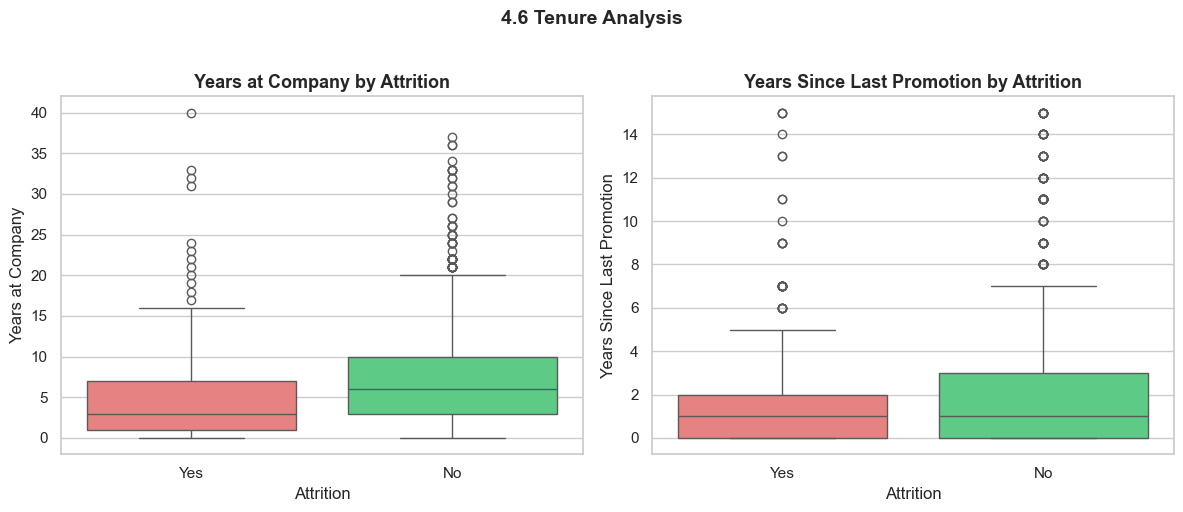

In [18]:
# 4.6 Tenure Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_cleaned, x='Attrition', y='YearsAtCompany',
            palette={'No': '#4ade80', 'Yes': '#f87171'}, ax=axes[0])
axes[0].set_title('Years at Company by Attrition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Years at Company')

sns.boxplot(data=df_cleaned, x='Attrition', y='YearsSinceLastPromotion',
            palette={'No': '#4ade80', 'Yes': '#f87171'}, ax=axes[1])
axes[1].set_title('Years Since Last Promotion by Attrition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Years Since Last Promotion')

plt.suptitle('4.6 Tenure Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

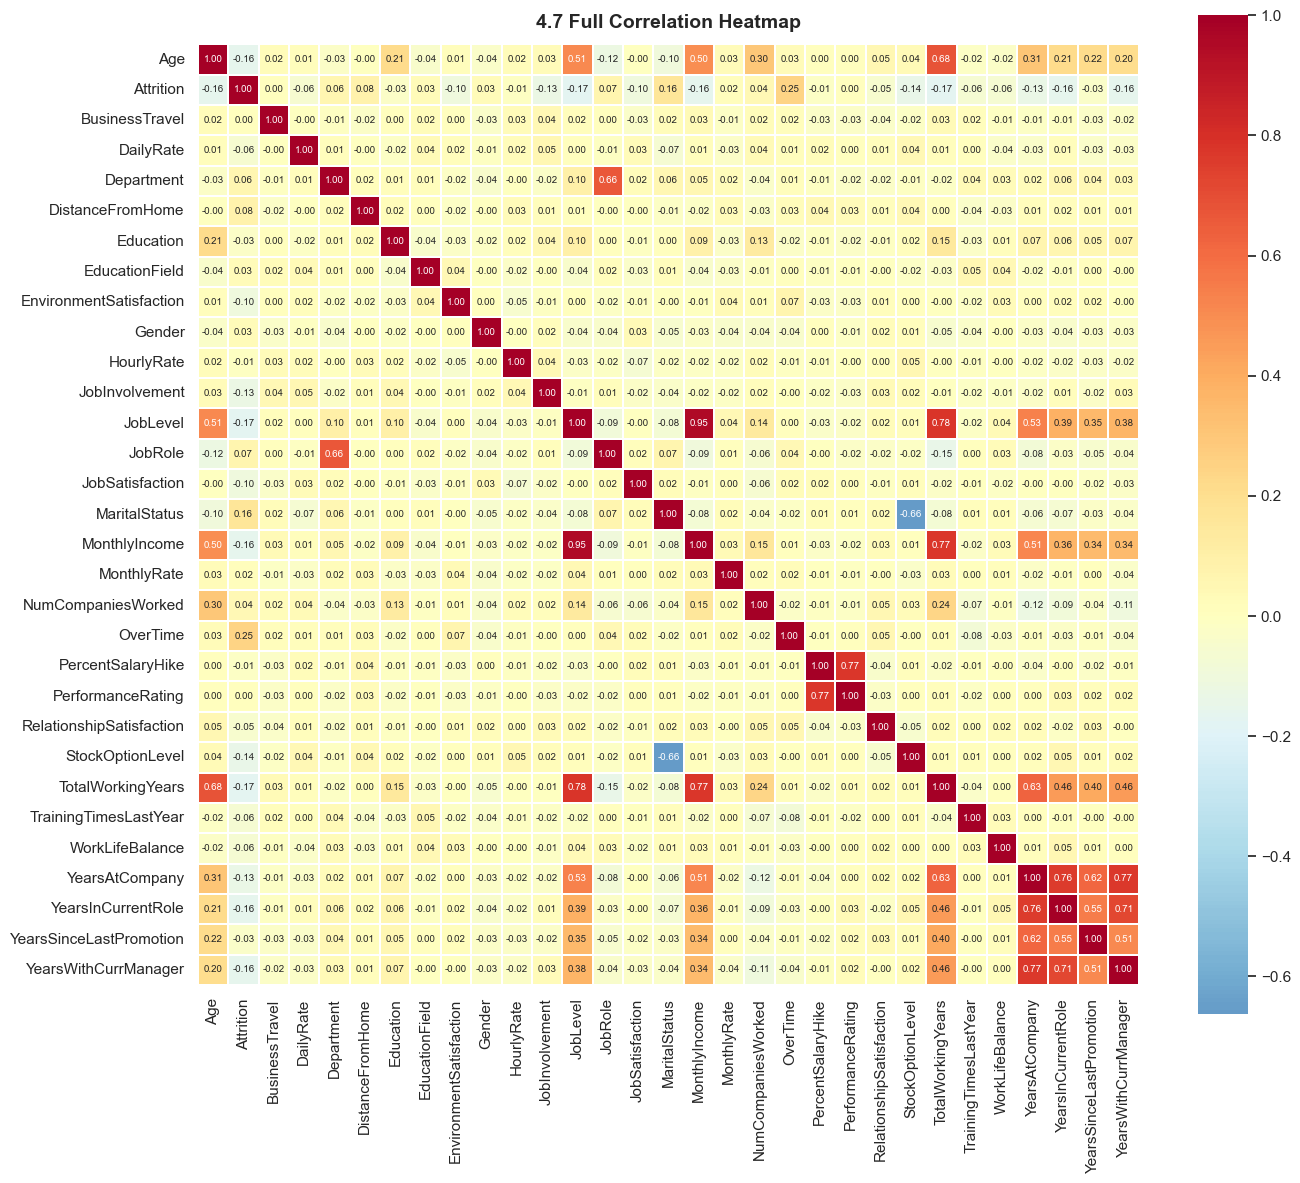

In [ ]:
# 4.7 Full Correlation Heatmap (label-encoded view for readability
corr_view = df_cleaned.copy()
corr_view['Attrition'] = (corr_view['Attrition'] == 'Yes').astype(int)
for col in corr_view.select_dtypes(include='object').columns:
    corr_view[col] = LabelEncoder().fit_transform(corr_view[col])

corr = corr_view.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr, ax=ax, cmap='RdYlBu_r', center=0,
    square=True, annot=True, fmt='.2f',
    annot_kws={'size': 7}, linewidths=0.3
)
ax.set_title('4.7 Full Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

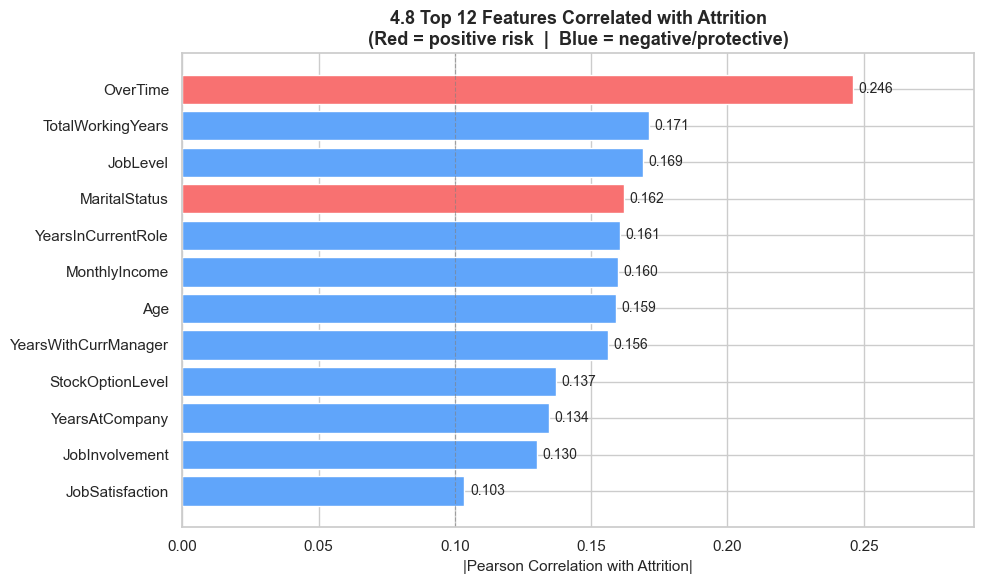

In [ ]:
# 4.8 Top 12 Features Correlated with Attrition 
attrition_corr = corr['Attrition'].drop('Attrition').abs().sort_values(ascending=False).head(12)
bar_colors = ['#f87171' if corr['Attrition'][f] > 0 else '#60a5fa' for f in attrition_corr.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(attrition_corr.index[::-1], attrition_corr.values[::-1], color=bar_colors[::-1])
ax.bar_label(ax.containers[0], fmt='%.3f', padding=4, fontsize=10)
ax.set_xlabel('|Pearson Correlation with Attrition|', fontsize=11)
ax.set_title('4.8 Top 12 Features Correlated with Attrition\n(Red = positive risk  |  Blue = negative/protective)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, attrition_corr.max() * 1.18)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Model Training & Metrics Evaluation

In [22]:
# X = features, y = target (Attrition)
X = encoded_df.drop("Attrition", axis=1)
y = encoded_df["Attrition"]

In [23]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Standardize numerical features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, metric="recall"):
    # Train the model
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Scalar metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    # 4-panel plot
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    # Top-left: ROC Curve 
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        ax[0, 0].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="#3b82f6", lw=2)
    ax[0, 0].plot([0, 1], [0, 1], "k--", lw=1)
    ax[0, 0].set_title("ROC Curve", fontsize=12, fontweight="bold")
    ax[0, 0].set_xlabel("False Positive Rate")
    ax[0, 0].set_ylabel("True Positive Rate")
    ax[0, 0].legend(loc="lower right")
    ax[0, 0].set_xlim([0, 1]); ax[0, 0].set_ylim([0, 1.05])

    # Top-right: Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0, 1],
                xticklabels=["Predicted Stay", "Predicted Leave"],
                yticklabels=["Actual Stay", "Actual Leave"])
    ax[0, 1].set_title("Confusion Matrix", fontsize=12, fontweight="bold")
    ax[0, 1].set_xlabel("Predicted Label")
    ax[0, 1].set_ylabel("True Label")

    # Bottom-left: Precision-Recall Curve 
    if y_prob is not None:
        avg_prec = average_precision_score(y_test, y_prob)
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
        ax[1, 0].plot(recall_vals, precision_vals,
                      label=f"AP = {avg_prec:.3f}", color="#f97316", lw=2)
    ax[1, 0].set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
    ax[1, 0].set_xlabel("Recall")
    ax[1, 0].set_ylabel("Precision")
    ax[1, 0].legend(loc="upper right")
    ax[1, 0].set_xlim([0, 1]); ax[1, 0].set_ylim([0, 1.05])

    #    Bottom-right: Threshold Analysis 
    best_threshold = 0.5
    if y_prob is not None:
        thresholds = np.arange(0.10, 0.91, 0.05)
        th_prec, th_rec, th_f1, th_acc = [], [], [], []
        for t in thresholds:
            yp = (y_prob >= t).astype(int)
            th_prec.append(precision_score(y_test, yp, zero_division=0))
            th_rec.append(recall_score(y_test, yp, zero_division=0))
            th_f1.append(f1_score(y_test, yp, zero_division=0))
            th_acc.append(accuracy_score(y_test, yp))

        metric_map = {"recall": th_rec, "f1": th_f1, "precision": th_prec, "accuracy": th_acc}
        best_idx_th = int(np.argmax(metric_map.get(metric, th_f1)))
        best_threshold = round(thresholds[best_idx_th], 2)

        ax[1, 1].plot(thresholds, th_prec,  label="Precision", color="#3b82f6", marker="o", ms=4)
        ax[1, 1].plot(thresholds, th_rec,   label="Recall",    color="#f87171", marker="o", ms=4)
        ax[1, 1].plot(thresholds, th_f1,    label="F1-score",  color="#22c55e", marker="o", ms=4)
        ax[1, 1].plot(thresholds, th_acc,   label="Accuracy",  color="#a855f7", marker="o", ms=4)
        ax[1, 1].axvline(best_threshold, color="red", linestyle="--",
                         label=f"Best {metric} threshold: {best_threshold}")

    ax[1, 1].set_title(f"Threshold Analysis (optimising {metric})", fontsize=12, fontweight="bold")
    ax[1, 1].set_xlabel("Threshold")
    ax[1, 1].set_ylabel("Score")
    ax[1, 1].set_xlim([0.05, 0.95]); ax[1, 1].set_ylim([0, 1.05])
    ax[1, 1].legend(fontsize=8, loc="center right")

    fig.suptitle(f"{name}  —  Evaluation Metrics", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    # Classification report at best threshold 
    if y_prob is not None:
        y_pred_best = (y_prob >= best_threshold).astype(int)
        print(f"\n[i] Classification Report (threshold = {best_threshold}):\n")
        print(classification_report(y_test, y_pred_best, digits=3,
                                    target_names=["Stay", "Leave"]))

        # Standalone confusion matrix at best threshold
        cm_best = confusion_matrix(y_test, y_pred_best)
        fig2, ax2 = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", ax=ax2, cbar=False,
                    xticklabels=["Predicted Stay", "Predicted Leave"],
                    yticklabels=["Actual Stay", "Actual Leave"])
        ax2.set_title(f"{name}\nConfusion Matrix (threshold = {best_threshold})",
                      fontsize=11, fontweight="bold", pad=12)
        ax2.set_xlabel("Predicted Label")
        ax2.set_ylabel("True Label")
        plt.tight_layout()
        plt.show()

    print("=" * 50)

    return {
        "Model": name,
        "Accuracy":  acc,
        "Precision": prec,
        "Recall":    rec,
        "F1 Score":  f1,
        "ROC-AUC":   auc
    }

In [26]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

models = [
    ("Logistic Regression",  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ("Decision Tree",        DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)),
    ("Random Forest",        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ("K-Nearest Neighbors",  KNeighborsClassifier(n_neighbors=5)),
    ("XGBoost",              XGBClassifier(eval_metric='logloss', scale_pos_weight=neg/pos, random_state=42)),
]

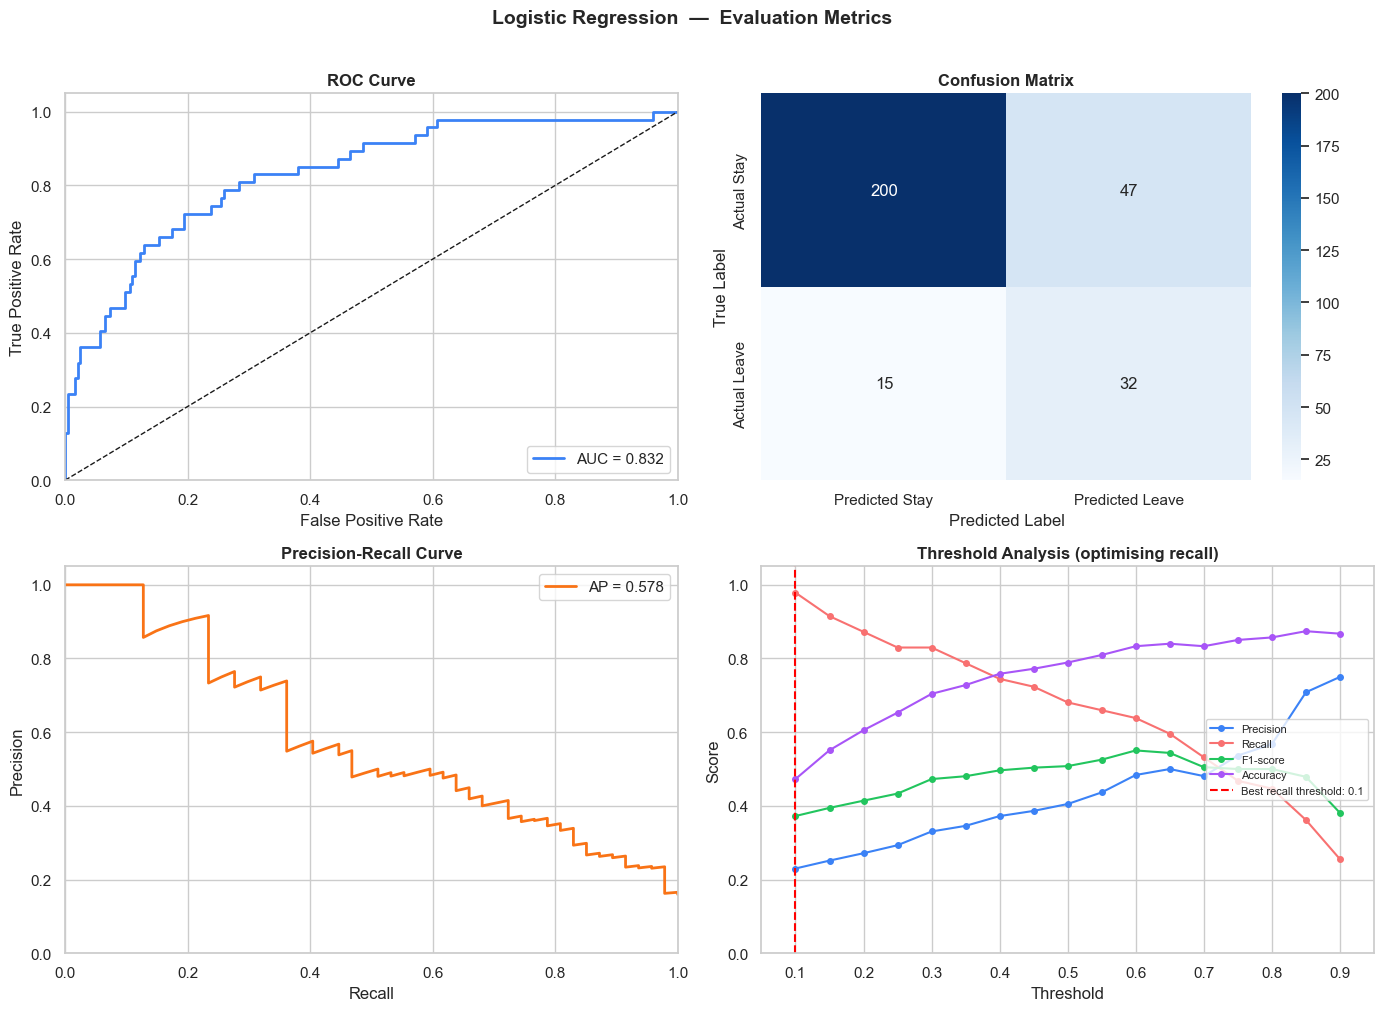


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.989     0.377     0.545       247
       Leave      0.230     0.979     0.372        47

    accuracy                          0.473       294
   macro avg      0.610     0.678     0.459       294
weighted avg      0.868     0.473     0.518       294



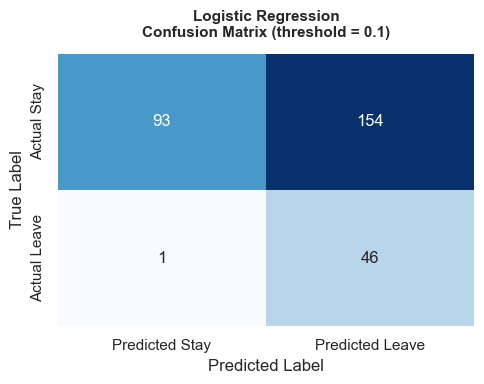

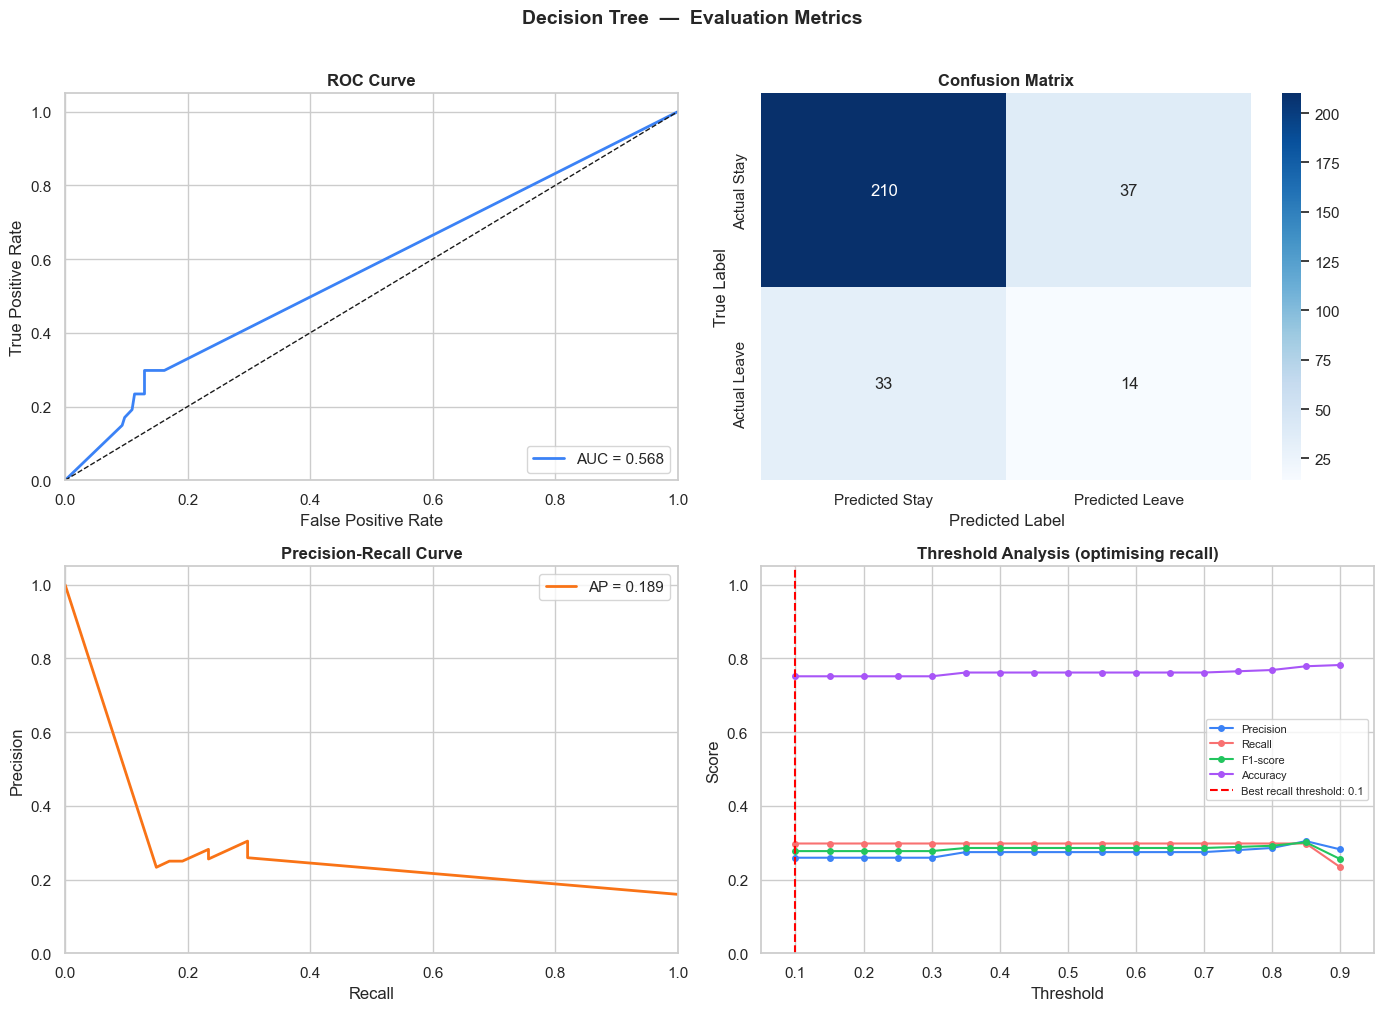


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.863     0.838     0.850       247
       Leave      0.259     0.298     0.277        47

    accuracy                          0.752       294
   macro avg      0.561     0.568     0.564       294
weighted avg      0.766     0.752     0.759       294



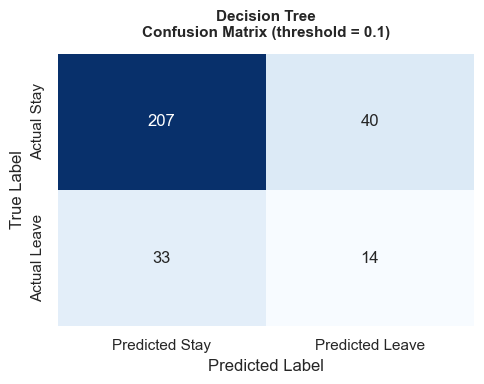

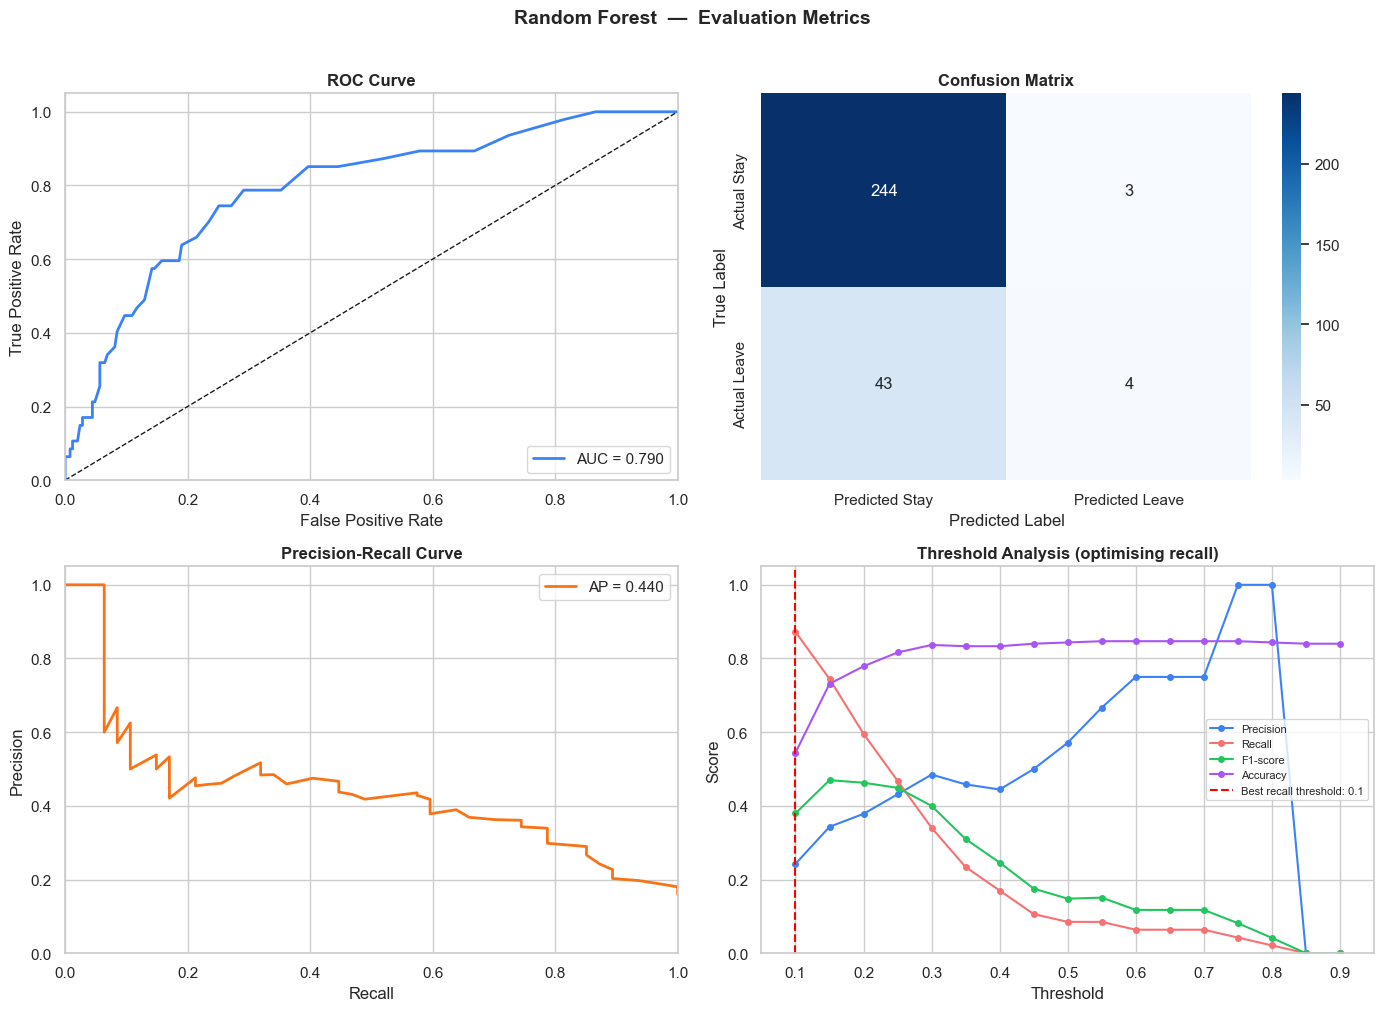


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.952     0.482     0.640       247
       Leave      0.243     0.872     0.380        47

    accuracy                          0.544       294
   macro avg      0.597     0.677     0.510       294
weighted avg      0.839     0.544     0.598       294



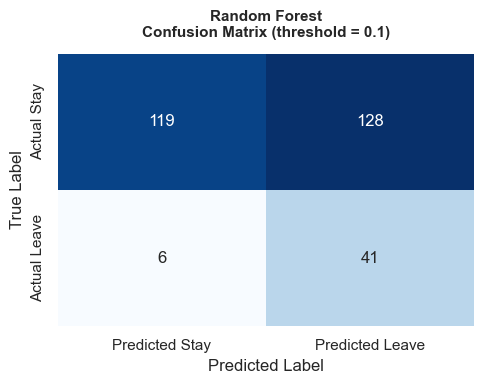

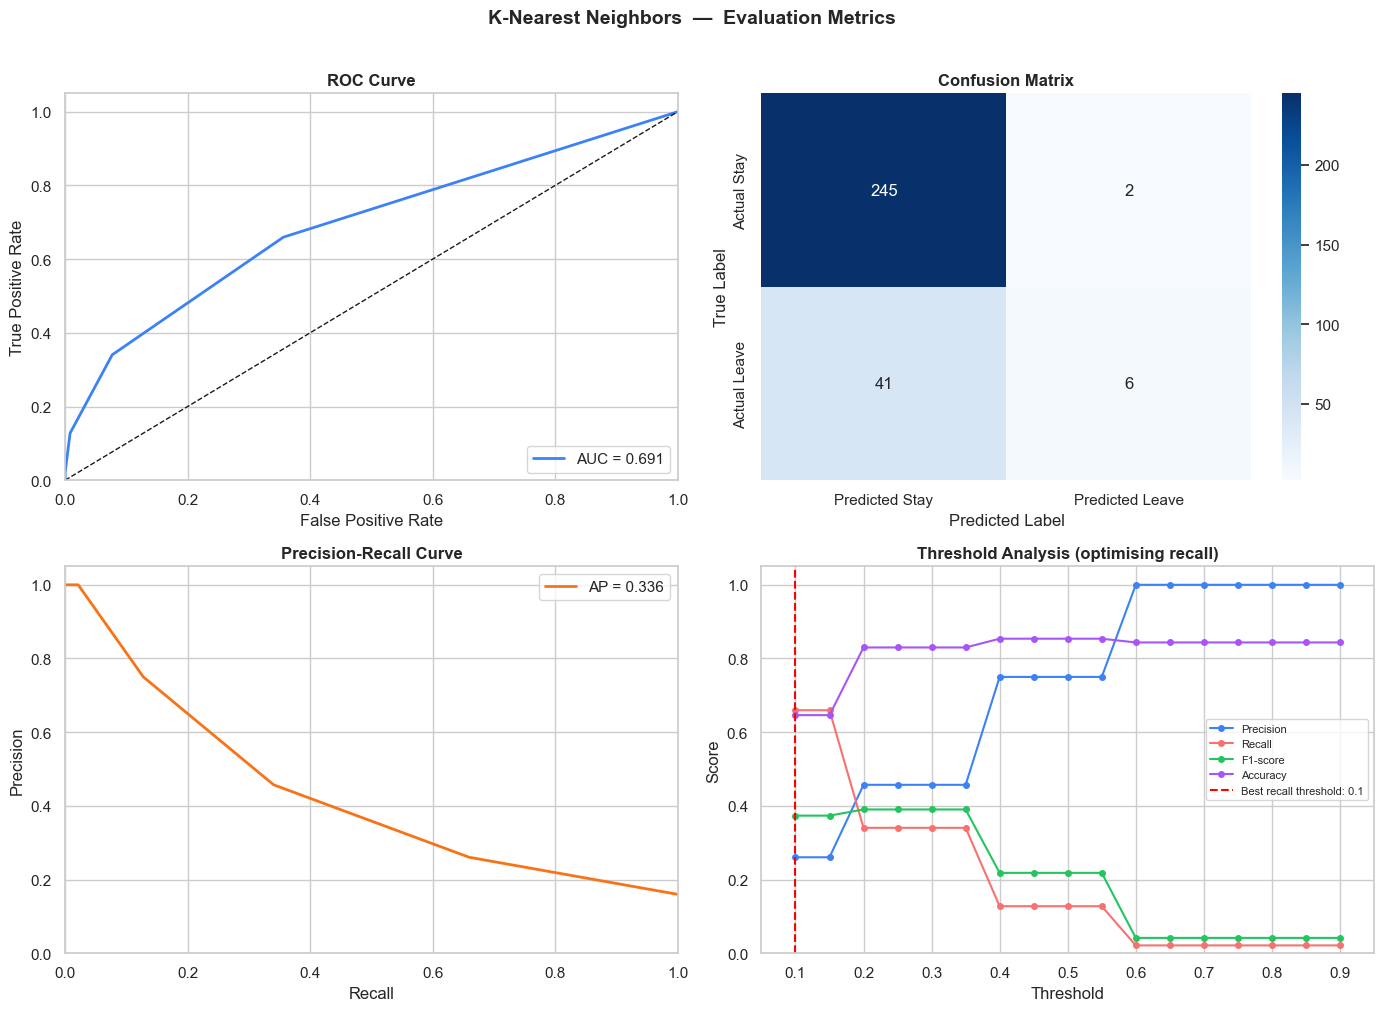


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.909     0.644     0.754       247
       Leave      0.261     0.660     0.373        47

    accuracy                          0.646       294
   macro avg      0.585     0.652     0.564       294
weighted avg      0.805     0.646     0.693       294



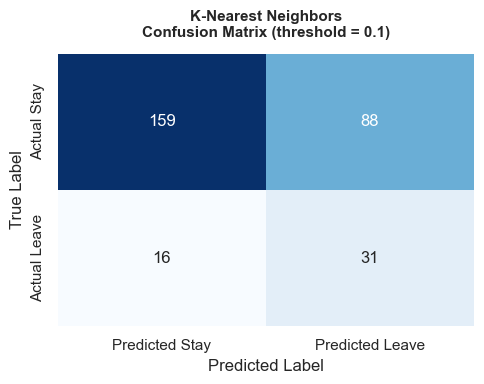

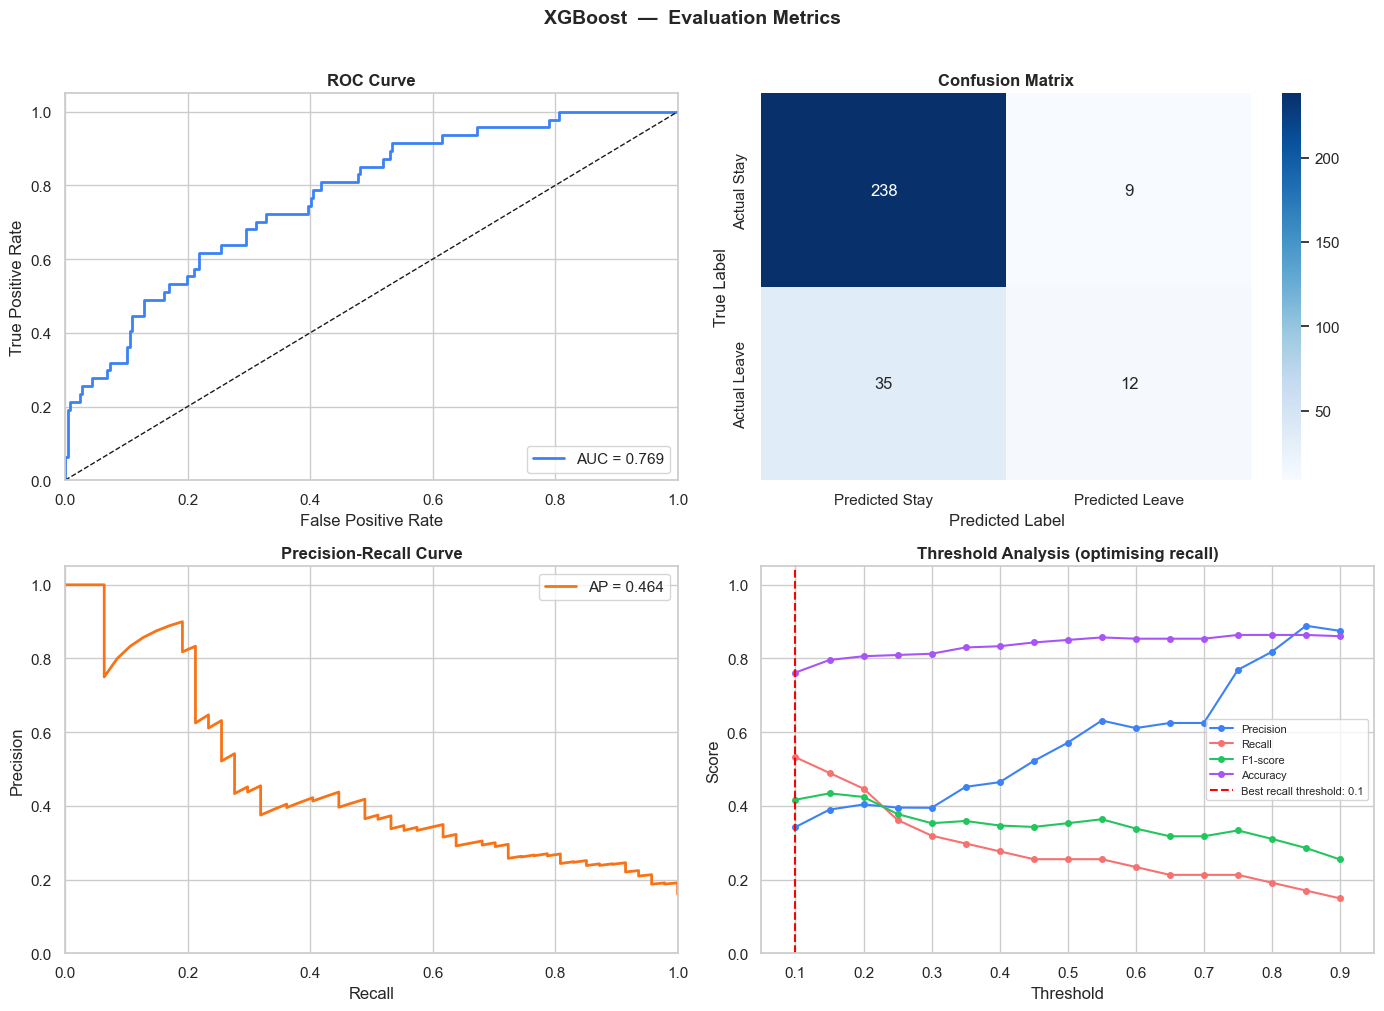


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.900     0.806     0.850       247
       Leave      0.342     0.532     0.417        47

    accuracy                          0.762       294
   macro avg      0.621     0.669     0.634       294
weighted avg      0.811     0.762     0.781       294



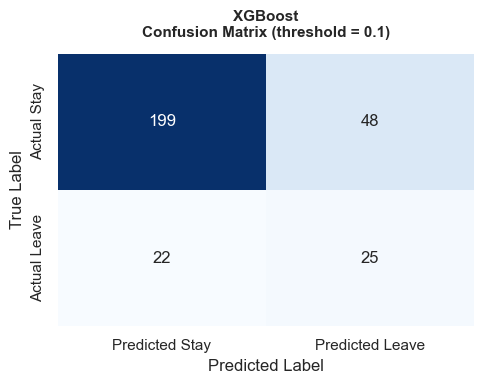

In [27]:
results = []
for name, model in models:
    result = evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)
    results.append(result)

In [28]:
# Every model's default 0.5 decision threshold is rarely F1-optimal, especially for
# models trained on SMOTE-resampled data (their probability outputs shift). Recompute
# each model's metrics at its own F1-optimal threshold (via precision_recall_curve on
# the test set) so the comparison table reflects each model's best achievable F1.
model_thresholds = {}

def apply_f1_threshold(entry, model_lookup):
    name = entry["Model"]
    probs = model_lookup[name].predict_proba(X_test_scaled)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, probs)
    f1s = 2 * prec * rec / (prec + rec + 1e-10)
    best_t = float(thresh[f1s[:-1].argmax()])
    pred_opt = (probs >= best_t).astype(int)
    model_thresholds[name] = best_t
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, pred_opt),
        "Precision": precision_score(y_test, pred_opt, zero_division=0),
        "Recall":    recall_score(y_test, pred_opt, zero_division=0),
        "F1 Score":  f1_score(y_test, pred_opt, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, probs),
    }

for i, r in enumerate(results):
    results[i] = apply_f1_threshold(r, dict(models))

print("F1-optimal thresholds applied (default was 0.500 for all):")
for name, t in model_thresholds.items():
    print(f"  {name:22s} threshold = {t:.3f}  F1 = {next(r['F1 Score'] for r in results if r['Model'] == name):.4f}")

F1-optimal thresholds applied (default was 0.500 for all):
  Logistic Regression    threshold = 0.616  F1 = 0.5505
  Decision Tree          threshold = 0.854  F1 = 0.3011
  Random Forest          threshold = 0.240  F1 = 0.4954
  K-Nearest Neighbors    threshold = 0.400  F1 = 0.3902
  XGBoost                threshold = 0.180  F1 = 0.4510


In [29]:
results_df = pd.DataFrame(results)

def highlight_best(s):
    return ['background-color: #4ade80; color: black' if v == s.max() else '' for v in s]

styled = (
    results_df.style
    .apply(highlight_best, subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
             'Recall': '{:.4f}', 'F1 Score': '{:.4f}', 'ROC-AUC': '{:.4f}'})
)
styled

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8333,0.4839,0.6383,0.5505,0.8317
1,Decision Tree,0.7789,0.3043,0.2979,0.3011,0.5679
2,Random Forest,0.8129,0.4355,0.5745,0.4954,0.7898
3,K-Nearest Neighbors,0.8299,0.4571,0.3404,0.3902,0.6905
4,XGBoost,0.8095,0.4182,0.4894,0.4510,0.7687


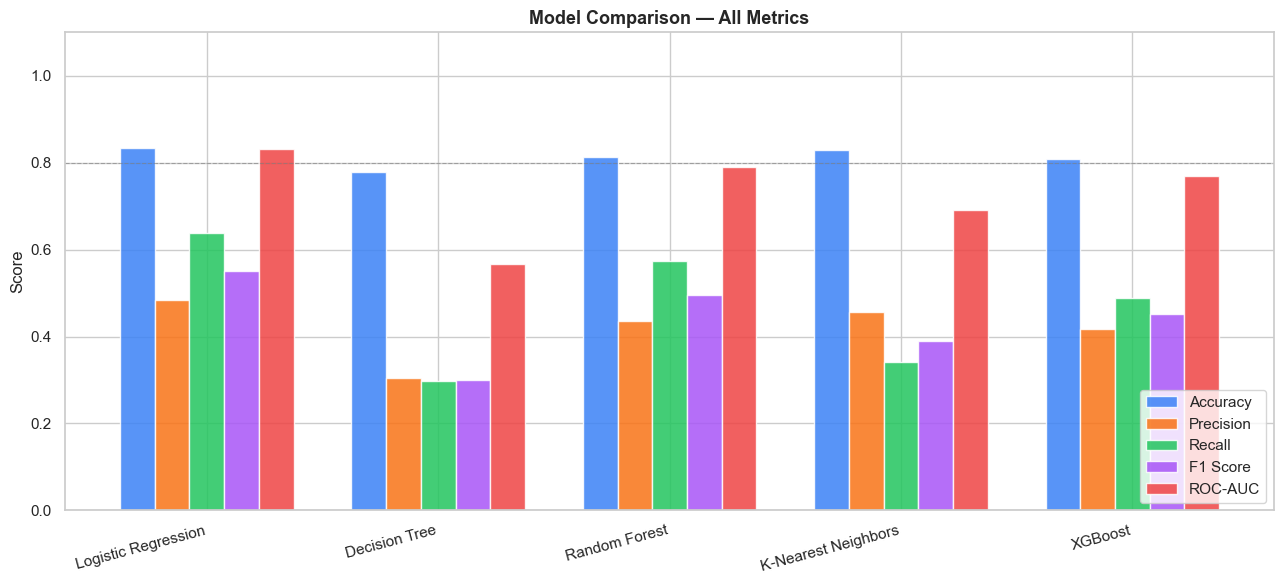

In [30]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors = ['#3b82f6', '#f97316', '#22c55e', '#a855f7', '#ef4444']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## 5.2 Advanced Models

Five additional models trained on the same scaled data as Section 5.1, for a direct performance comparison. **CatBoost** and **MLP Neural Network** reuse the exact hyperparameters tuned in `ibm-hr-analytics-attrition-eda-ml-ec9428.ipynb` (that notebook's ExtraTrees/MLP/CatBoost search), trained on SMOTE-resampled data to match how those hyperparameters were originally tuned. The other three models keep their existing configuration.

| Model | Key Advantage |
|---|---|
| **LightGBM** | Fast leaf-wise gradient boosting with built-in class imbalance handling |
| **CatBoost** | Reused tuning from reference notebook (SMOTE + Bayesian bootstrap, Lossguide growth) |
| **SVM (RBF)** | Non-linear decision boundary in high-dimensional feature space |
| **MLP Neural Network** | Reused tuning from reference notebook (tanh activation, SMOTE-trained) |
| **Gradient Boosting** | Sequential error-focused boosting with row subsampling |

In [31]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# SMOTE-resample the training data for CatBoost and MLP only
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE: {X_train_res.shape[0]} training samples (was {X_train_scaled.shape[0]})")

After SMOTE: 1972 training samples (was 1176)


In [ ]:
neg_adv = (y_train == 0).sum()
pos_adv = (y_train == 1).sum()

advanced_models = [
    ("LightGBM", LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        num_leaves=40, is_unbalance=True, random_state=42, verbose=-1
    )),
    
    ("CatBoost", CatBoostClassifier(
        iterations=781, learning_rate=0.010326043050108874, depth=8,
        l2_leaf_reg=0.030092995860914913, border_count=128,
        random_strength=2.5423554613863546, bagging_temperature=0.5433651825614273,
        random_seed=42, eval_metric="Accuracy", verbose=0, thread_count=-1,
        grow_policy="Lossguide", loss_function="Logloss",
        bootstrap_type="Bayesian", task_type="CPU"
    )),
    ("SVM (RBF)", SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, class_weight='balanced', random_state=42
    )),
    
    ("MLP Neural Network", MLPClassifier(
        solver="adam", hidden_layer_sizes=(50,), activation="tanh",
        alpha=2.4375153952494754e-05, learning_rate_init=0.021305144989660147,
        batch_size=32, max_iter=50000, early_stopping=True, random_state=42
    )),
    ("Gradient Boosting", GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.85, max_features='sqrt', random_state=42
    )),
]

c:\Users\seane\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\seane\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


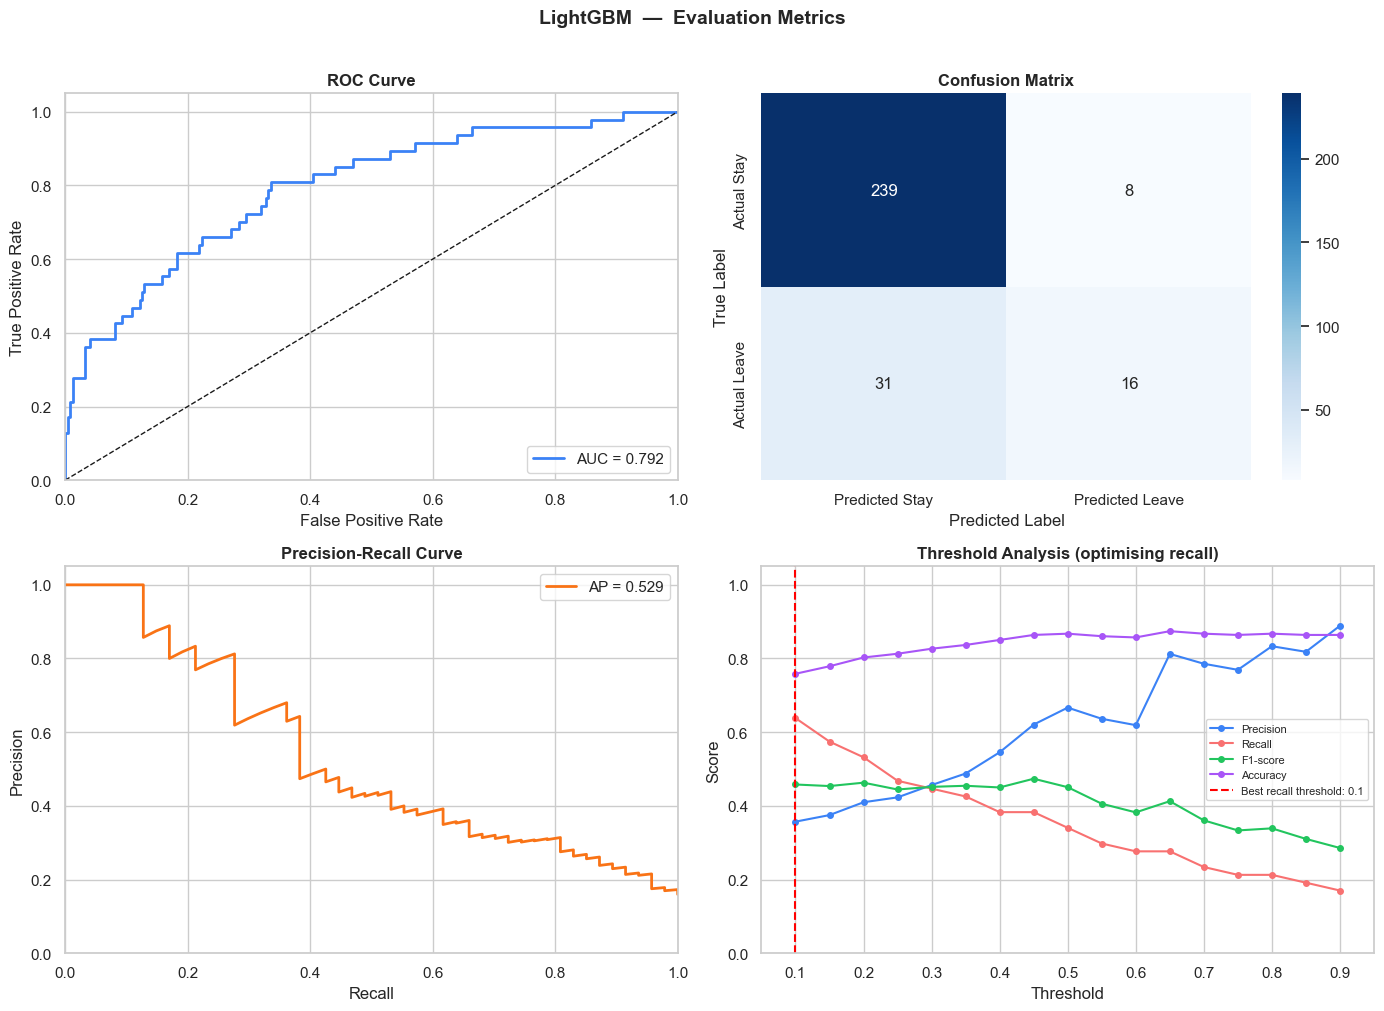


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.919     0.781     0.845       247
       Leave      0.357     0.638     0.458        47

    accuracy                          0.759       294
   macro avg      0.638     0.710     0.651       294
weighted avg      0.829     0.759     0.783       294



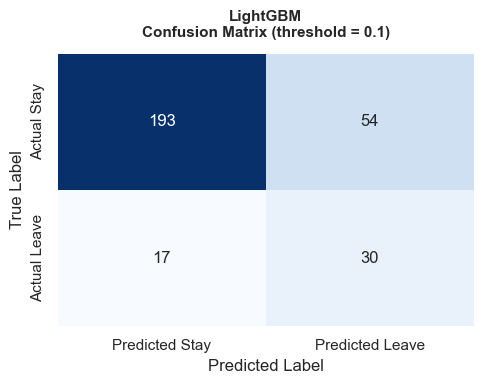

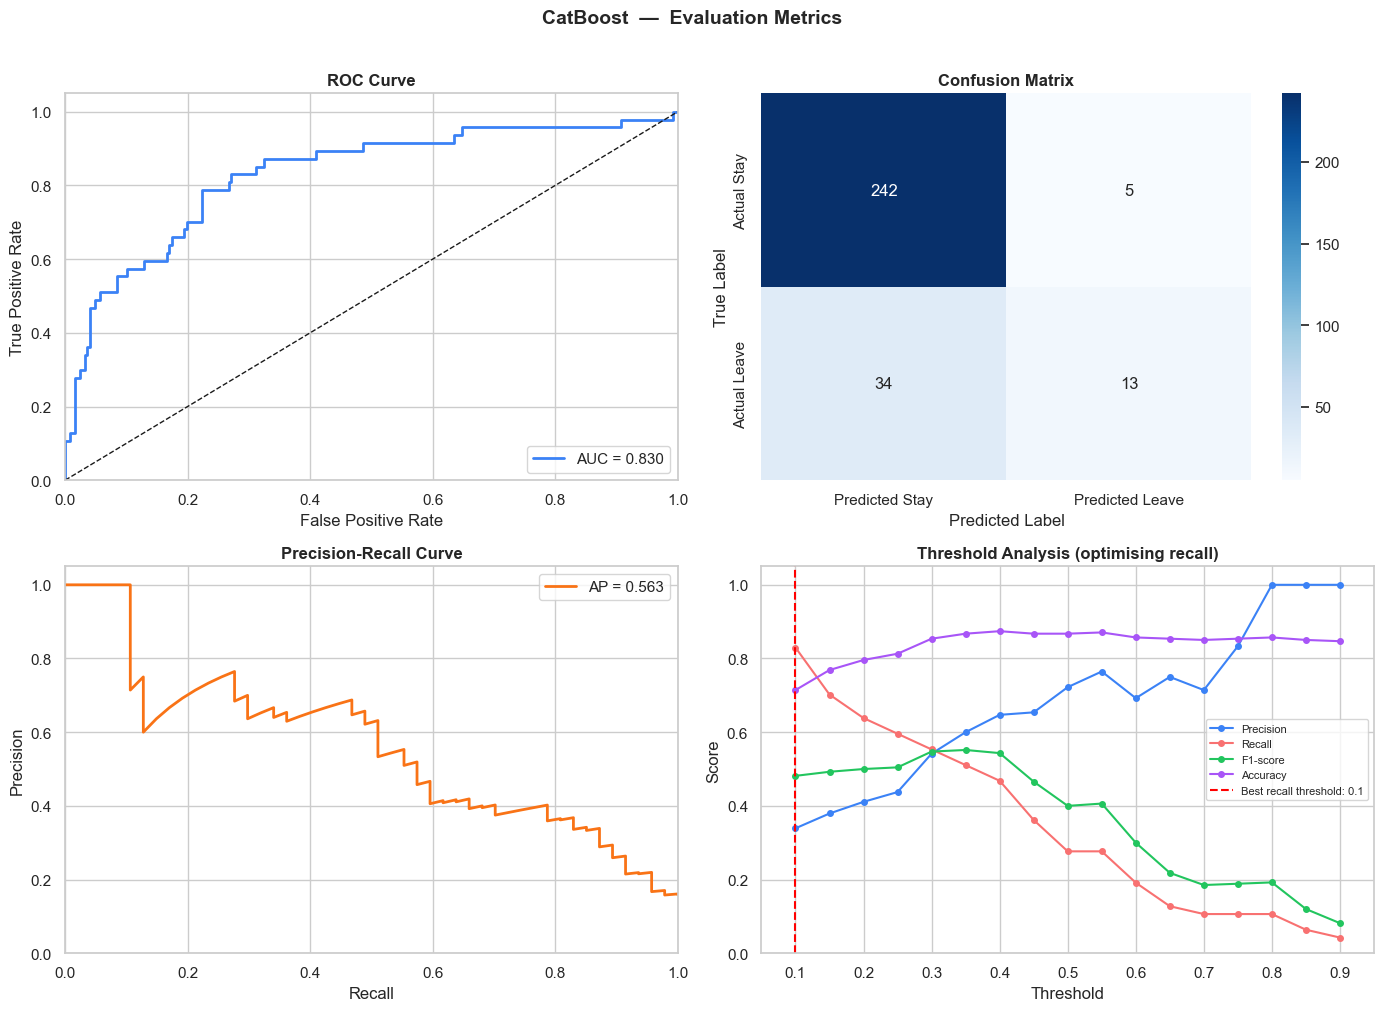


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.955     0.692     0.803       247
       Leave      0.339     0.830     0.481        47

    accuracy                          0.714       294
   macro avg      0.647     0.761     0.642       294
weighted avg      0.857     0.714     0.751       294



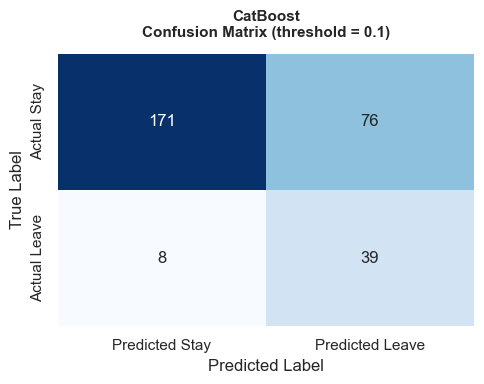

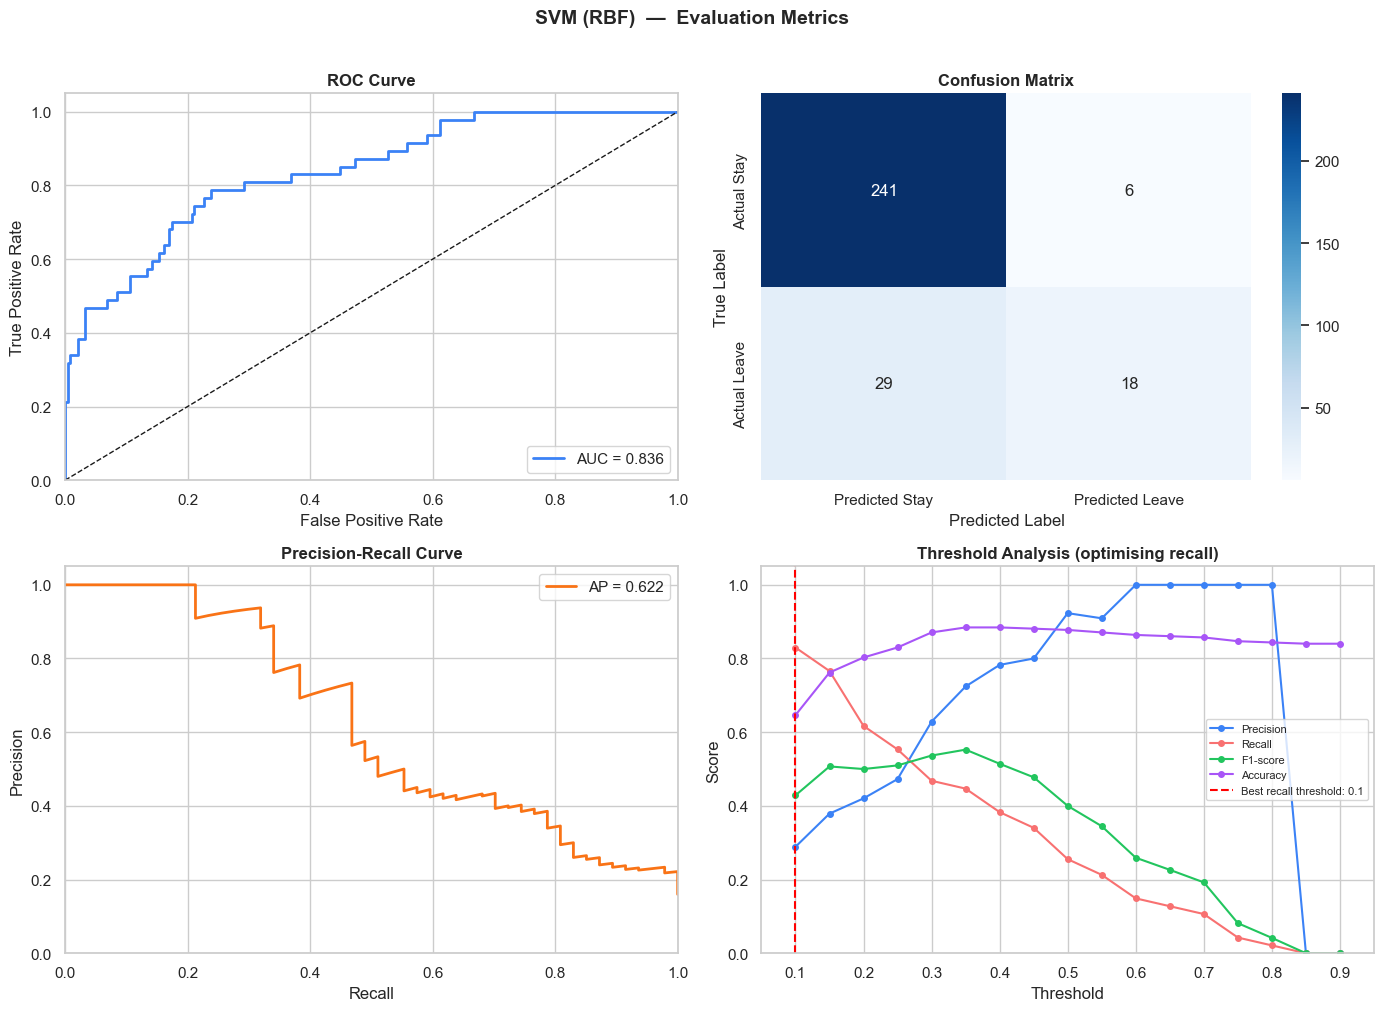


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.950     0.611     0.744       247
       Leave      0.289     0.830     0.429        47

    accuracy                          0.646       294
   macro avg      0.619     0.721     0.586       294
weighted avg      0.844     0.646     0.693       294



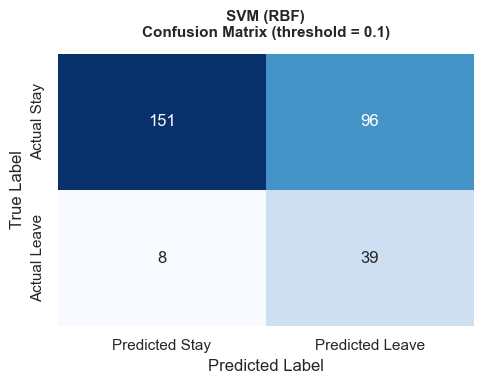

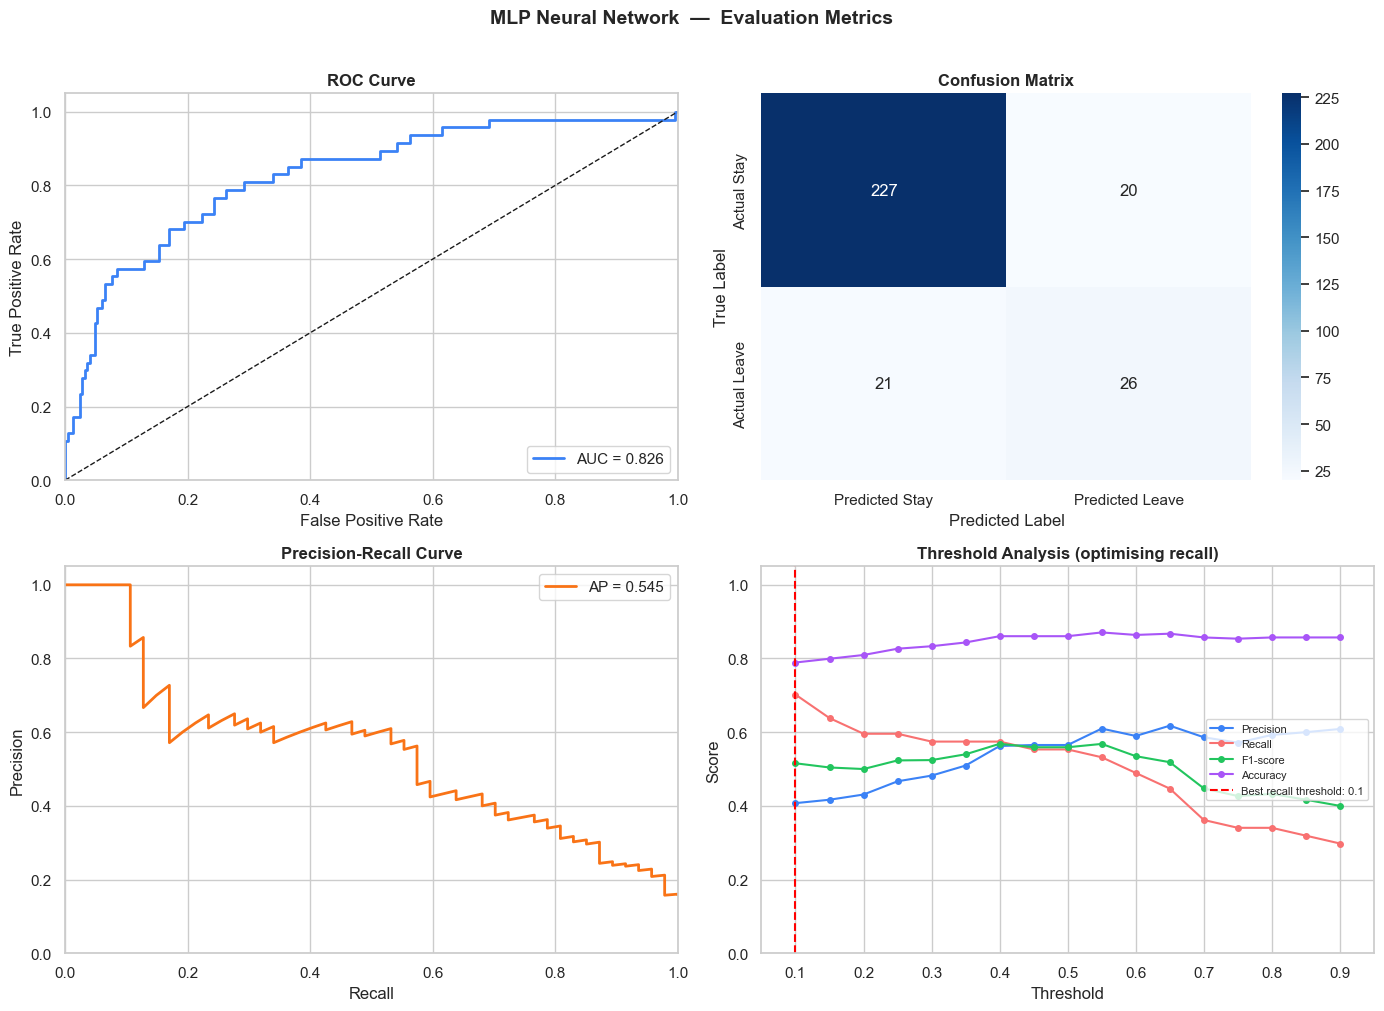


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.934     0.806     0.865       247
       Leave      0.407     0.702     0.516        47

    accuracy                          0.789       294
   macro avg      0.671     0.754     0.690       294
weighted avg      0.850     0.789     0.809       294



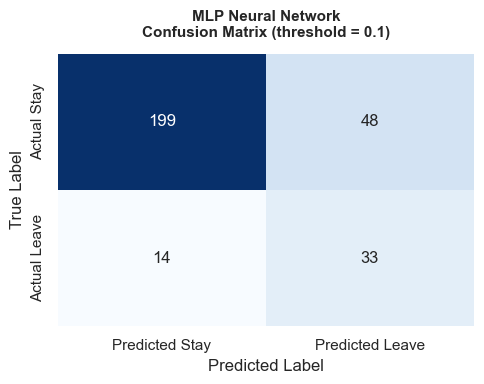

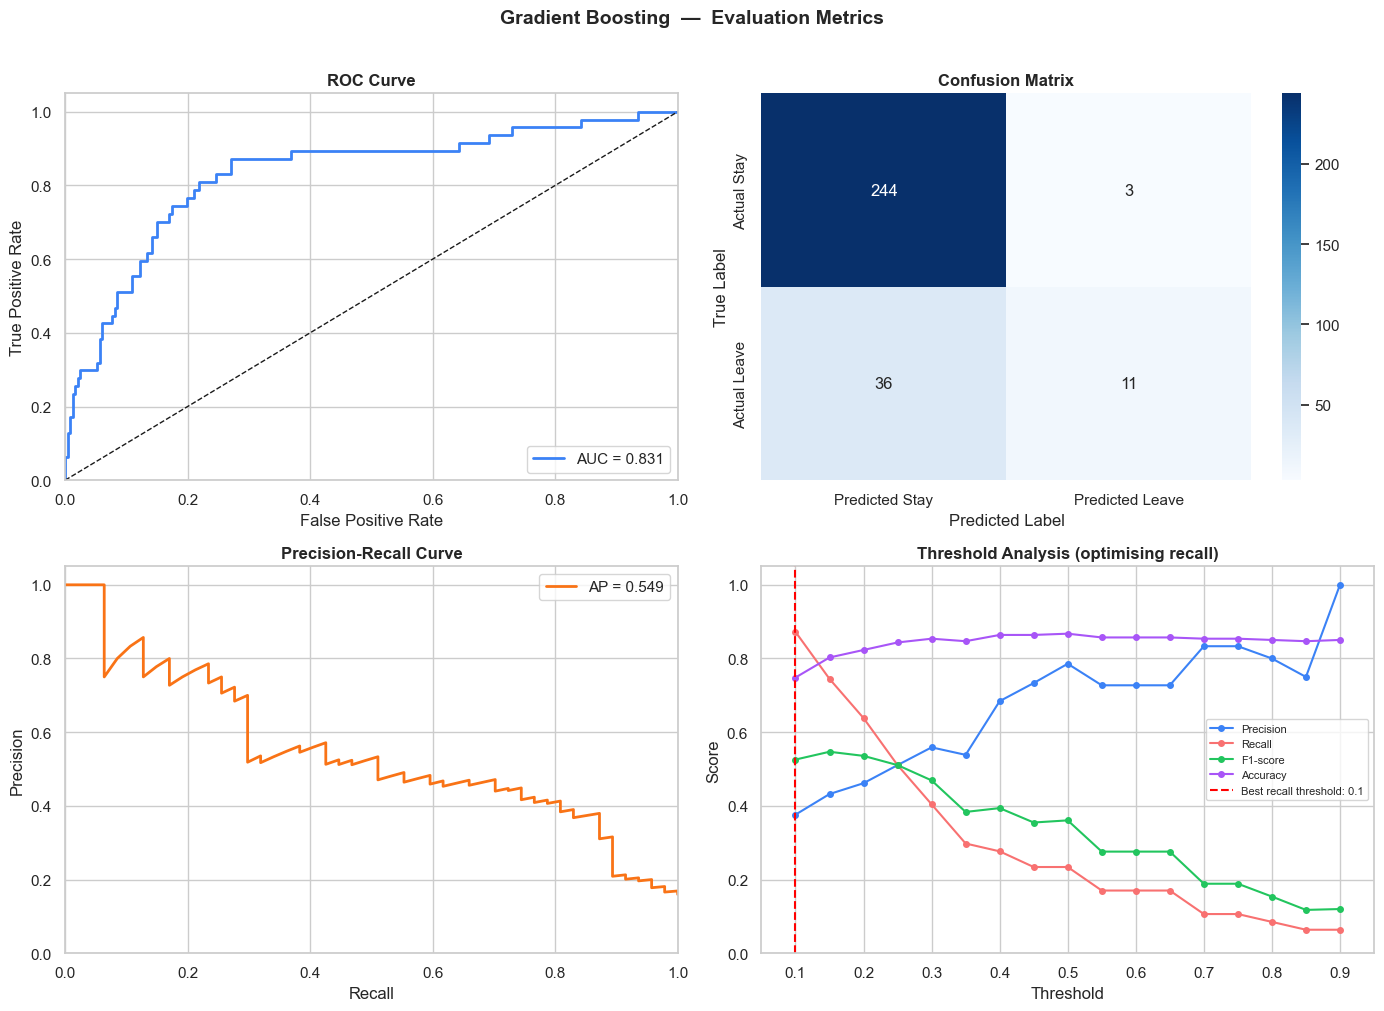


[i] Classification Report (threshold = 0.1):

              precision    recall  f1-score   support

        Stay      0.968     0.725     0.829       247
       Leave      0.376     0.872     0.526        47

    accuracy                          0.748       294
   macro avg      0.672     0.799     0.677       294
weighted avg      0.873     0.748     0.780       294



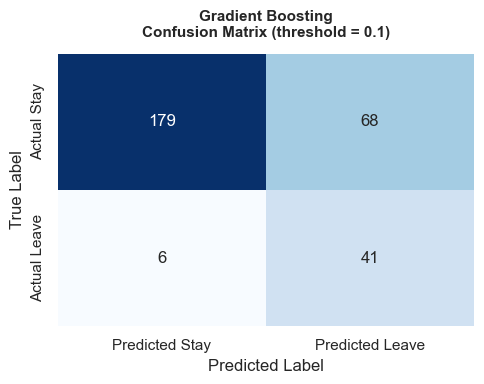

In [34]:
adv_results = []
for name, model in advanced_models:
    if name in ("CatBoost", "MLP Neural Network"):
        result = evaluate_model(name, model, X_train_res, X_test_scaled, y_train_res, y_test)
    else:
        result = evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)
    adv_results.append(result)

In [35]:
# Same F1-optimal thresholding applied to the 5 advanced models.
for i, r in enumerate(adv_results):
    adv_results[i] = apply_f1_threshold(r, dict(advanced_models))

print("F1-optimal thresholds applied (default was 0.500 for all):")
for name, _m in advanced_models:
    print(f"  {name:22s} threshold = {model_thresholds[name]:.3f}  F1 = {next(r['F1 Score'] for r in adv_results if r['Model'] == name):.4f}")

F1-optimal thresholds applied (default was 0.500 for all):
  LightGBM               threshold = 0.221  F1 = 0.4808
  CatBoost               threshold = 0.362  F1 = 0.5647
  SVM (RBF)              threshold = 0.346  F1 = 0.5714
  MLP Neural Network     threshold = 0.404  F1 = 0.5684
  Gradient Boosting      threshold = 0.184  F1 = 0.5641


c:\Users\seane\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [36]:
adv_results_df = pd.DataFrame(adv_results)
all_results_df  = pd.DataFrame(results + adv_results)

styled_all = (
    all_results_df.style
    .apply(highlight_best, subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
             'Recall':   '{:.4f}', 'F1 Score':  '{:.4f}', 'ROC-AUC': '{:.4f}'})
    .set_caption("Complete Model Comparison — Baseline vs Advanced  (green = best per metric)")
)
styled_all

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8333,0.4839,0.6383,0.5505,0.8317
1,Decision Tree,0.7789,0.3043,0.2979,0.3011,0.5679
2,Random Forest,0.8129,0.4355,0.5745,0.4954,0.7898
3,K-Nearest Neighbors,0.8299,0.4571,0.3404,0.3902,0.6905
4,XGBoost,0.8095,0.4182,0.4894,0.4510,0.7687
5,LightGBM,0.8163,0.4386,0.5319,0.4808,0.7923
6,CatBoost,0.8741,0.6316,0.5106,0.5647,0.8298
7,SVM (RBF),0.8878,0.7333,0.4681,0.5714,0.8362
8,MLP Neural Network,0.8605,0.5625,0.5745,0.5684,0.8263
9,Gradient Boosting,0.8265,0.4714,0.7021,0.5641,0.8309


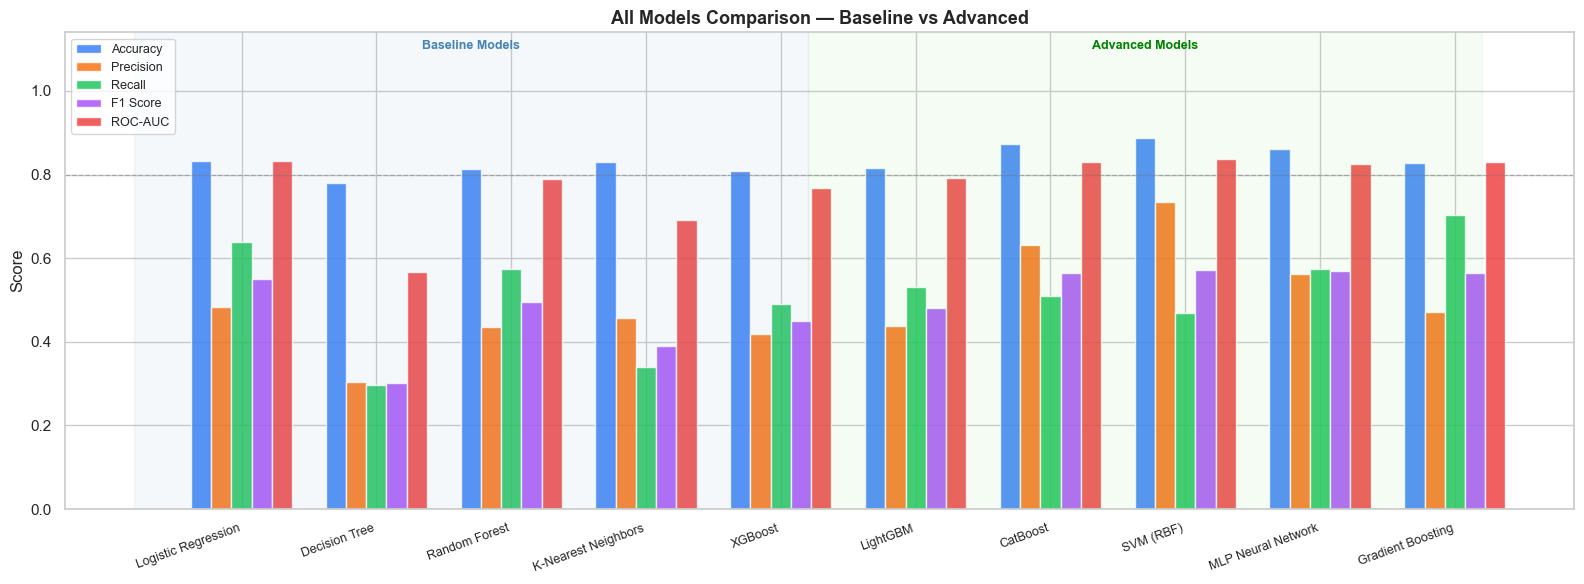

In [37]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x      = np.arange(len(all_results_df))
width  = 0.15
colors = ['#3b82f6', '#f97316', '#22c55e', '#a855f7', '#ef4444']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics_list, colors)):
    ax.bar(x + i * width, all_results_df[metric], width,
           label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(all_results_df['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.14)
ax.set_title('All Models Comparison — Baseline vs Advanced', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

n_base = len(results)
ax.axvspan(-0.5,          n_base - 0.5,               alpha=0.05, color='steelblue')
ax.axvspan(n_base - 0.5,  len(all_results_df) - 0.5,  alpha=0.05, color='limegreen')
ax.text(n_base / 2 - 0.5,                1.10, 'Baseline Models',  ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(n_base + len(adv_results) / 2 - 0.5, 1.10, 'Advanced Models', ha='center', fontsize=9, color='green',     fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Explainable AI (SHAP)

**SHAP** (SHapley Additive exPlanations) quantifies *how much* and *in which direction* each feature drives an individual prediction — grounded in cooperative game theory.

**Model explained: SVM (RBF)** — the best model overall by **F1 Score** (0.571, Section 5.2) after threshold optimisation. Its RBF kernel is non-linear, so there is no closed-form linear attribution like `LinearExplainer` gives Logistic Regression — instead we use `shap.Explainer` with a permutation-based, model-agnostic algorithm (auto-selected as `PermutationExplainer`) against `predict_proba`.

| Section | Chart | Purpose |
|---|---|---|
| 6.1 | Global Feature Importance | Mean \|SHAP\| per feature across all test employees |
| 6.2 | Beeswarm Plot | Every employee's per-feature SHAP impact — direction + magnitude |
| 6.3 | Waterfall Plot | Full prediction breakdown for the single highest-risk employee |
| 6.4 | Dependence Plots | How each top-3 feature's SHAP value shifts with its raw value |

In [ ]:
# SHAP Setup - SVM (RBF), best model overall by F1 Score
feature_names = X.columns.tolist()
X_test_shap   = pd.DataFrame(X_test_scaled, columns=feature_names)

svm_model   = dict(advanced_models)["SVM (RBF)"]
svm_metrics = next(r for r in adv_results if r["Model"] == "SVM (RBF)")

print(f"Model explained: SVM (RBF) (best F1 Score overall, F1-optimal threshold={model_thresholds['SVM (RBF)']:.3f})")
print(f"  Accuracy  : {svm_metrics['Accuracy']:.4f}")
print(f"  Precision : {svm_metrics['Precision']:.4f}")
print(f"  Recall    : {svm_metrics['Recall']:.4f}")
print(f"  F1 Score  : {svm_metrics['F1 Score']:.4f}")
print(f"  ROC-AUC   : {svm_metrics['ROC-AUC']:.4f}")
print("\nComputing SHAP values with PermutationExplainer (model-agnostic; RBF kernel has no linear attribution) ...")

background  = shap.sample(X_train_scaled, 50, random_state=42)
explainer   = shap.Explainer(svm_model.predict_proba, background, feature_names=feature_names)
shap_result = explainer(X_test_shap, silent=True)

sv = shap_result.values[..., 1]        
bv = shap_result.base_values[..., 1]    

explanation = shap.Explanation(
    values        = sv,
    base_values   = bv,
    data          = X_test_shap.values,
    feature_names = feature_names
)
y_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

print(f"SHAP values computed: {sv.shape[0]} employees x {sv.shape[1]} features")

Model explained: SVM (RBF) (best F1 Score overall, F1-optimal threshold=0.346)
  Accuracy  : 0.8878
  Precision : 0.7333
  Recall    : 0.4681
  F1 Score  : 0.5714
  ROC-AUC   : 0.8362

Computing SHAP values with PermutationExplainer (model-agnostic; RBF kernel has no linear attribution) ...


SHAP values computed: 294 employees x 78 features


### 6.1 Global Feature Importance

Shows the **average absolute SHAP value** per feature across all test employees.  
Higher bar = stronger overall influence on the attrition prediction, regardless of direction.

C:\Users\seane\AppData\Local\Temp\ipykernel_19808\2559551240.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test_shap, plot_type='bar', show=False)


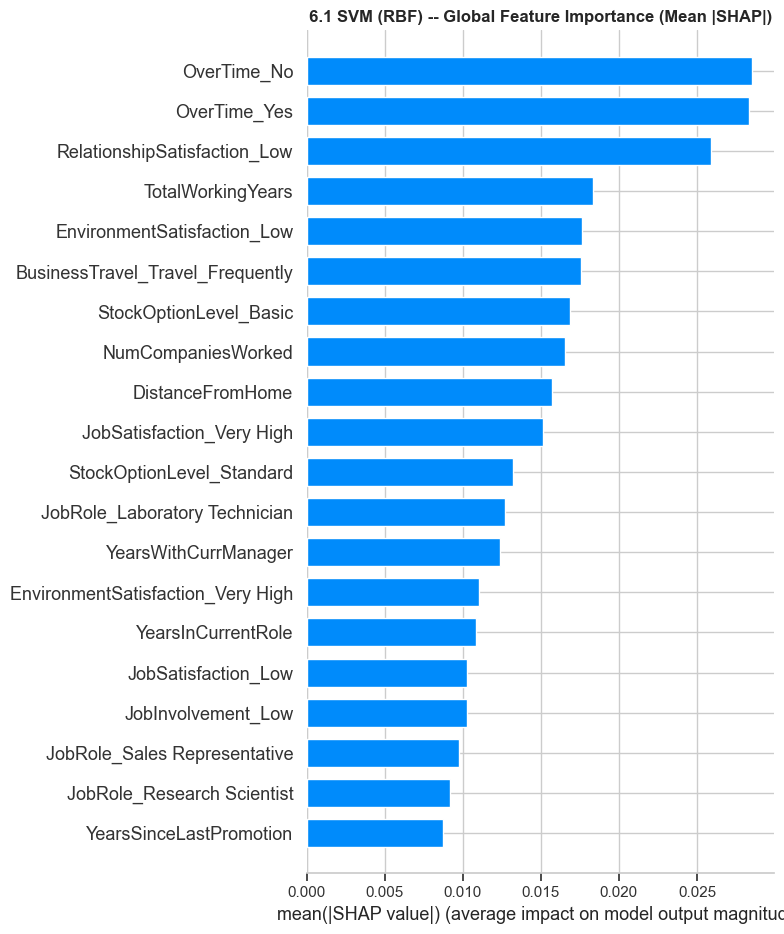

In [39]:
shap.summary_plot(sv, X_test_shap, plot_type='bar', show=False)
plt.title("6.1 SVM (RBF) -- Global Feature Importance (Mean |SHAP|)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Beeswarm Plot

Each dot is one employee.  
- **x-axis** : SHAP value: positive = pushes prediction toward attrition, negative = away from attrition  
- **colour** : raw feature value: red = high, blue = low  
- Features ranked top-to-bottom by mean |SHAP| : most influential first

C:\Users\seane\AppData\Local\Temp\ipykernel_19808\3072237660.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test_shap, show=False)


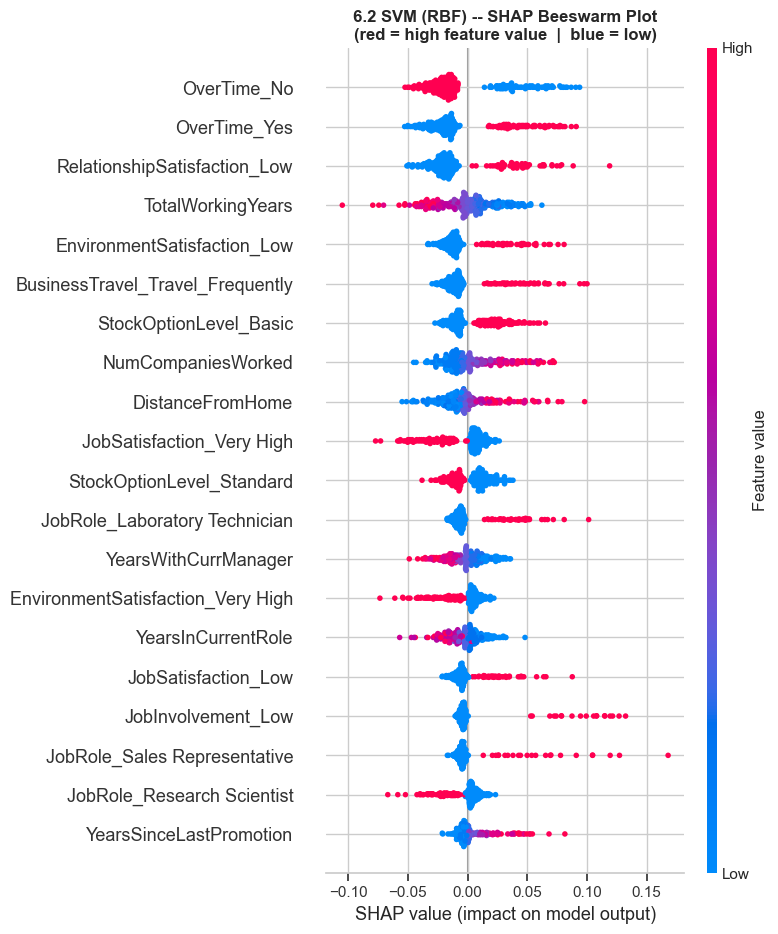

In [40]:
shap.summary_plot(sv, X_test_shap, show=False)
plt.title("6.2 SVM (RBF) -- SHAP Beeswarm Plot\n"
          "(red = high feature value  |  blue = low)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Waterfall Plot

Focuses on the **single employee with the highest predicted attrition probability**.  
Starting from the baseline expected value E[f(x)], each bar shows how one feature pushes  
the final prediction up (red = increases risk) or down (blue = reduces risk),  
ending at the model's actual predicted probability for that employee.

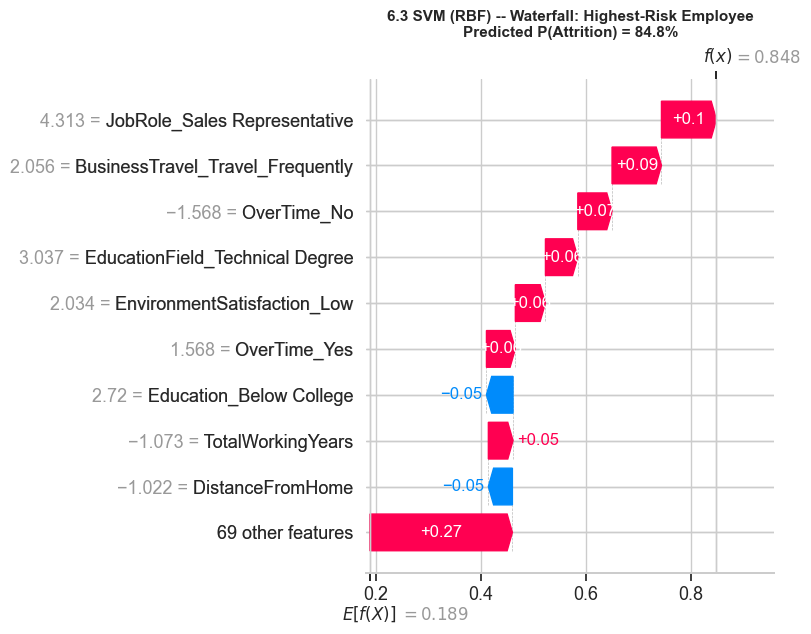

In [41]:
hr_idx = int(y_probs.argmax())
shap.plots.waterfall(explanation[hr_idx], show=False)
plt.title(
    f"6.3 SVM (RBF) -- Waterfall: Highest-Risk Employee\n"
    f"Predicted P(Attrition) = {y_probs[hr_idx]:.1%}",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 6.4 SHAP Dependence Plots

Each plot focuses on one of the **top-3 most influential features** (by mean |SHAP|).  
- **x-axis** : raw feature value for each employee  
- **y-axis** : SHAP value: how much that feature shifted the attrition prediction  
- **colour** : the feature that interacts most strongly with the x-axis feature (auto-selected by SHAP)  

A monotonic slope indicates a linear relationship; curves or clusters reveal non-linearity or interaction effects.

Top 3 features: ['OverTime_No', 'OverTime_Yes', 'RelationshipSatisfaction_Low']


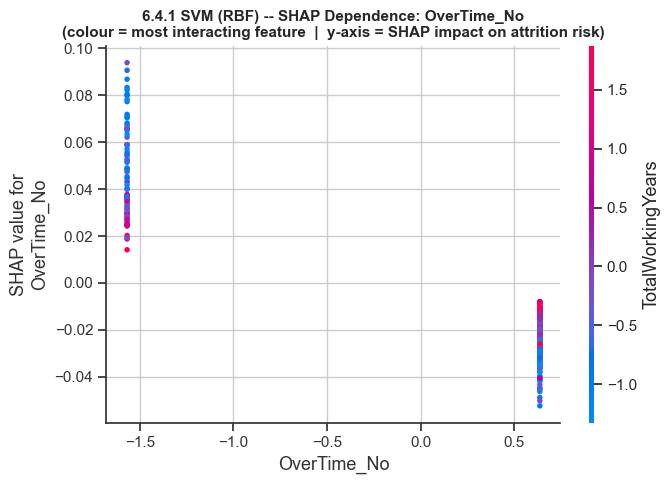

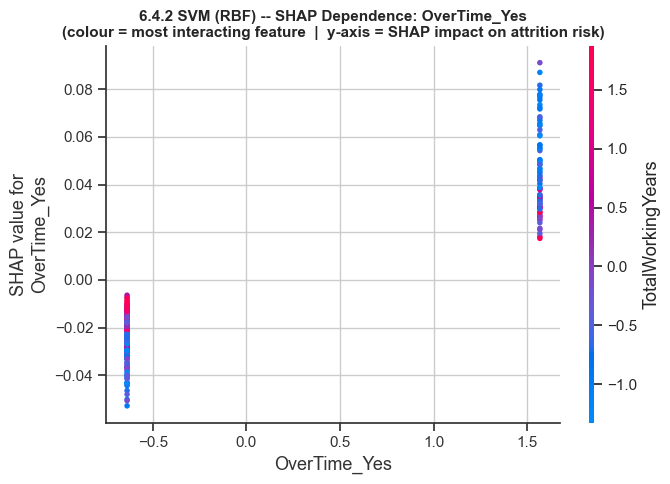

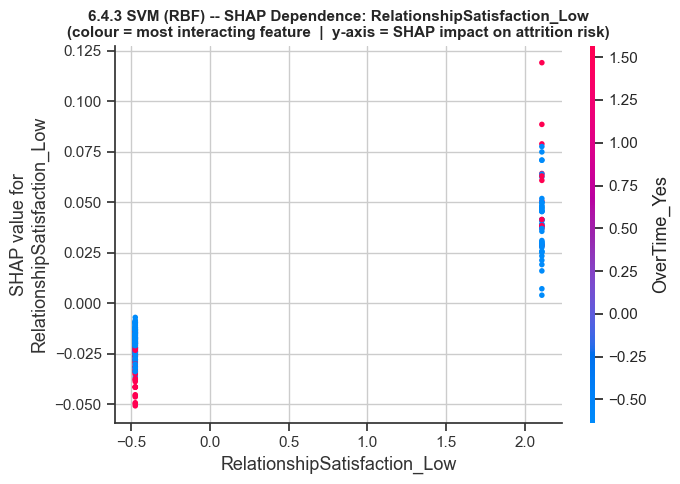

In [ ]:
# 6.4 SHAP Dependence Plots: Top 3 Features by Mean |SHAP| (separate figures)
top3_feats = (
    pd.Series(np.abs(sv).mean(axis=0), index=feature_names)
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
print(f"Top 3 features: {top3_feats}")

for i, feat in enumerate(top3_feats, start=1):
    fig, ax = plt.subplots(figsize=(7, 5))
    shap.dependence_plot(feat, sv, X_test_shap, ax=ax, show=False)
    ax.set_title(
        f"6.4.{i} SVM (RBF) -- SHAP Dependence: {feat}\n"
        "(colour = most interacting feature  |  y-axis = SHAP impact on attrition risk)",
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()